<a href="https://colab.research.google.com/github/AndikaPutra509/Prediksi-Saham/blob/main/Quant_Medallion_Style_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ V2.0 Dependencies imported (Lightweight Quant Models)

🏦 IDX STOCK SCANNER V2.0 - Medallion Style
   Models: Kelly | CAPM | GBM | MVO | VaR/CVaR
✅ Google Sheets connected

📊 Google Sheets: https://docs.google.com/spreadsheets/d/1zBPiByXJh0NpKdusOnsnOZPGyAH_w0178vx8l65jFEI

Pilih Mode:
1. Inisialisasi Data Warehouse
2. Phase 1 - Trading Scanner (Kelly + CAPM + GBM + MVO + VaR)
3. System Quality Dashboard (Backtest End-to-End)
4. Exit

Pilihan (1/2/3/4): 3
  Interval scan (hari, default=10): 10
  Holding period (hari, default=10): 14
  Modal simulasi (Rp, default=5000000): 200000

📊 SYSTEM QUALITY DASHBOARD V2.0 (Lightweight)
Periode: 2006-04-16 – 2026-04-11 | Saham: 589
Interval: 10 hari | Holding: 14 hari | Modal: Rp 200,000

📡 FETCHING GLOBAL INDICES

📊 IHSG: Indeks Harga Saham Gabungan (^JKSE)
   ✅ Harga: 7,458.50

📊 DOWJONES: Dow Jones Industrial Average (^DJI)
   ✅ Harga: 47,916.57

📊 USDIDR: USD/IDR (IDR=X)
   ✅ Harga: Rp 17,059

📊 OIL: Crude Oil WTI (CL=F)
   ✅ Harga: US$ 96.57

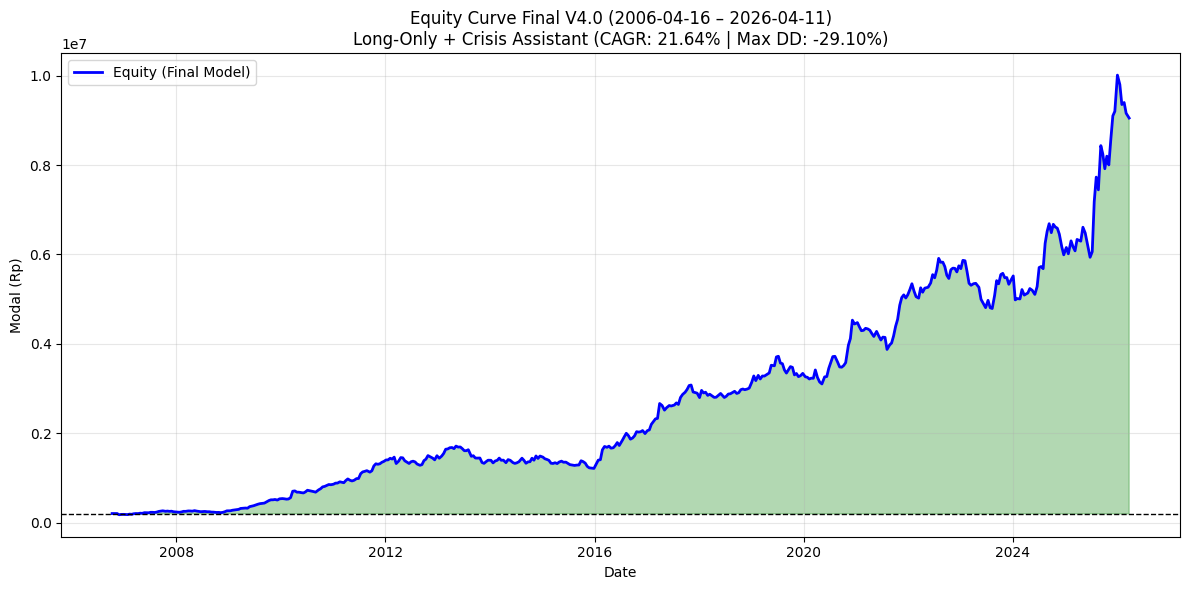

In [4]:
# -*- coding: utf-8 -*-
"""IDX Stock Scanner - Medallion Style V2.0
================================================================================
VERSI 2.0 - LIGHTWEIGHT QUANT MODELS (Fast & Efficient for Google Colab Free)
================================================================================
Model yang diintegrasikan (BARU - Ringan):
  1. Kelly Criterion (1/4 Fractional) - Position Sizing per signal quality
  2. CAPM (Capital Asset Pricing Model) - Risk/Return Benchmark vs IHSG
  3. GBM (Geometric Brownian Motion, Vectorized) - Price Simulation
  4. Mean-Variance Optimization (Markowitz + Ledoit-Wolf Shrinkage)
  5. VaR / CVaR - Portfolio Risk Metric (informational + lot adjuster)

DIHAPUS vs V2.0 (Model Berat):
  - GARCH, HMM, ARIMA, Linear Regression, Kalman Filter, LSTM
  - Library: hmmlearn, pmdarima, pykalman, simdkalman, tensorflow

MITIGASI OVERFITTING:
  - Semua model closed-form (ZERO iterasi training)
  - Rolling window 60 hari untuk semua kalkulasi statistik
  - Ledoit-Wolf shrinkage pada matriks kovarians MVO
  - 1/4 Kelly (conservative), bounded [0.5x, 2.0x] base lot
  - Beta CAPM dibatasi [-2.0, 3.0] (realistic IDX range)
  - GBM: sigma floor 0.5%, cap 15%, mu winsorized ke [-2%, +2%]
  - Semua model memiliki fallback jika data tidak cukup
  - LightweightSignalEnhancer: HANYA menambah info, TIDAK pernah memblokir sinyal

TARGET KECEPATAN:
  - Scanner: <5 menit (was >30 menit di V2.0)
  - Backtest: ~30-45 menit (was >3 jam di V2.0)
================================================================================
"""

# =============================================================================
# 0. INSTALL LIBRARY (MINIMAL - TANPA LIBRARY BERAT)
# =============================================================================
# Jalankan cell ini terlebih dahulu di Google Colab
!pip install -q ta mplfinance alphalens-reloaded seaborn statsmodels
!pip install -q scikit-learn yfinance tabulate vectorbt

# =============================================================================
# 1. DEPENDENCIES & IMPORTS
# =============================================================================
import mplfinance as mpf
import matplotlib.pyplot as plt
try:
    from google.colab import auth
    from google.auth import default
    import gspread
    _COLAB_AVAILABLE = True
except ImportError:
    _COLAB_AVAILABLE = False

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
from datetime import datetime, timedelta
import time
import pickle
import os
import json
from tabulate import tabulate
from collections import defaultdict
import logging
import random
from typing import Optional, Dict, List, Tuple, Union, Any
import hashlib
import math
import ta
import glob
from scipy.stats import norm

warnings.filterwarnings('ignore')
logging.basicConfig(filename='scanner_errors.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("✅ V2.0 Dependencies imported (Lightweight Quant Models)")

# =============================================================================
# 2. STOCK UNIVERSE (SAMA PERSIS DENGAN V2.0)
# =============================================================================
STOCKBIT_UNIVERSE = [
    "AALI", "ABBA", "ABDA", "ABMM", "ACES", "ADES", "ADHI", "ADMF", "ADMG", "ADRO",
    "AGAR", "AGII", "AGRO", "AHAP", "AIMS", "AISA", "AKRA", "AKSI", "ALDO", "ALKA",
    "ALMI", "AMAG", "AMFG", "AMMN", "AMRT", "ANDI", "ANJT", "ANTM", "APEX", "APIC",
    "APLN", "ARCI", "ARGO", "ARII", "ARNA", "ARTA", "ARTO", "ASBI", "ASDM", "ASGR",
    "ASHA", "ASII", "ASLI", "ASMI", "ASPI", "ASRI", "ASRM", "ASSA", "ATLA", "AUTO",
    "AVIA", "AWAN", "AYLS", "BABP", "BACA", "BALI", "BANK", "BAPA", "BAPI", "BATA",
    "BAYU", "BBCA", "BBHI", "BBKP", "BBLD", "BBNI", "BBRI", "BBRM", "BBSS", "BBTN",
    "BBYB", "BCAP", "BCIC", "BDMN", "BEEF", "BEKS", "BELL", "BEST", "BFIN", "BGTG",
    "BHAT", "BIMA", "BINA", "BIPP", "BIPI", "BIRD", "BISI", "BJBR", "BJTM", "BKSL",
    "BLTA", "BLUE", "BMAS", "BMBL", "BMRI", "BMSR", "BMTR", "BNBA", "BNBR", "BNGA",
    "BNII", "BNLI", "BOBA", "BOLT", "BOSS", "BPFI", "BPII", "BPTR", "BRAM", "BREN",
    "BRIS", "BRMS", "BRNA", "BRPT", "BSDE", "BSIM", "BSSR", "BTEL", "BTON", "BTPN",
    "BTPS", "BUDI", "BULL", "BUMI", "BUVA", "BWPT", "BYAN", "CAMP", "CANI", "CARS",
    "CASA", "CASS", "CBDK", "CBMF", "CCSI", "CDAX", "CEKA", "CENT", "CFIN", "CITA",
    "CITY", "CKRA", "CLEO", "CLPI", "CMNP", "CMPP", "CMRY", "CNKO", "CNTX", "COAL",
    "COCO", "COWL", "CPIN", "CPRO", "CSAP", "CSIS", "CTBN", "CTRA", "CTTH", "CUAN",
    "DAAZ", "DART", "DASA", "DAYA", "DCII", "DEGA", "DEWA", "DFAM", "DGIK", "DIGI",
    "DILD", "DIVA", "DIVN", "DKFT", "DLTA", "DMAS", "DMND", "DNAR", "DNET", "DNLS",
    "DOID", "DOOH", "DPNS", "DPUM", "DSFI", "DSNG", "DSSA", "DUCK", "DUTI", "DVLA",
    "DYAN", "EASI", "EASY", "EBMT", "ECII", "EDGE", "EKAD", "ELBA", "ELSA", "ELTY",
    "EMBR", "EMDE", "EMTK", "ENRG", "ENVY", "ENZO", "EPAC", "EPMT", "ERAA", "ERTX",
    "ESSA", "ESTA", "ESTI", "ETWA", "EXCL", "FAST", "FASW", "FILM", "FISH", "FITT",
    "FKSF", "FLMC", "FMII", "FORE", "FORU", "FORZ", "FPNI", "FREN", "FUJI", "FUTR",
    "GAMA", "GDST", "GDYR", "GEMS", "GGRM", "GGRP", "GHON", "GIDS", "GJTL", "GLVA",
    "GMFI", "GMTD", "GOLD", "GOOD", "GOTO", "GPRA", "GRPH", "GSMF", "GTBO", "GTRA",
    "GTSI", "GULA", "GZCO", "HADE", "HDFA", "HDIT", "HEAL", "HERO", "HITS", "HKMU",
    "HMSP", "HOKI", "HOMI", "HOPE", "HOTL", "HRME", "HRTA", "HRUM", "HSBK", "HSMP",
    "HUMI", "IBFN", "IBOS", "IBST", "ICBP", "ICON", "IDPR", "IFII", "IFSH", "IGAR",
    "IIKP", "IKAI", "IKAN", "IMAS", "IMJS", "IMPC", "INAF", "INAI", "INCF", "INCI",
    "INCO", "INDF", "INDS", "INDX", "INDY", "INET", "INKP", "INPC", "INPP", "INPS",
    "INRU", "INTA", "INTD", "INTP", "IPCC", "IPCM", "IPOL", "IRRA", "ISAT", "ISEA",
    "ISSP", "ITIC", "ITMG", "JAST", "JAWA", "JAYA", "JECC", "JEMB", "JFAS", "JGLE",
    "JHON", "JIHD", "JKON", "JKSW", "JMAS", "JPFA", "JPII", "JPUR", "JRPT", "JSKY",
    "JSMR", "JSPT", "JTNB", "KAEF", "KAQI", "KARW", "KBLI", "KBLM", "KBRT", "KBRI",
    "KDSI", "KDTN", "KEEN", "KETR", "KICI", "KIJA", "KINO", "KIOS", "KJEN", "KKGI",
    "KLBF", "KMTR", "KOBX", "KOIN", "KOLI", "KONI", "KOTA", "KPAL", "KPIG", "KRAS",
    "KREN", "KRYA", "KSEL", "KUAS", "KUIC", "KUVO", "LAND", "LAPD", "LATA", "LBAK",
    "LCGP", "LCKM", "LEAD", "LIFE", "LINK", "LION", "LISA", "LMAS", "LMPI", "LMSH",
    "LPCK", "LPGI", "LPIN", "LPKR", "LPLI", "LPPF", "LPPS", "LSIP", "LSPI", "LTLS",
    "LUCY", "MABA", "MABH", "MAGP", "MAIN", "MAMI", "MAPA", "MAPB", "MAPI", "MARA",
    "MASA", "MAYA", "MBAP", "MBCA", "MBMA", "MBSS", "MBTO", "MCAS", "MCPI", "MCOR",
    "MDIA", "MDKA", "MDKI", "MEDC", "MEDS", "MEGA", "MERK", "META", "MFIN", "MFMI",
    "MGLV", "MGNA", "MGRO", "MIDI", "MIKA", "MINA", "MIRA", "MITI", "MITT", "MKNT",
    "MKPI", "MLBI", "MLIA", "MLPL", "MLPT", "MLSL", "MMIX", "MMLP", "MNCN", "MOLI",
    "MPOW", "MPPA", "MPRO", "MPTJ", "MRAT", "MSIE", "MSIN", "MSKY", "MTDL", "MTFN",
    "MTLA", "MTPS", "MTSM", "MUDA", "MUTU", "MYOH", "MYOR", "MYRX", "MYSX", "NAGA",
    "NASI", "NATO", "NAYZ", "NCKL", "NELY", "NETV", "NFCX", "NICL", "NIKL", "NISP",
    "NITY", "NIYM", "NOBU", "NPGF", "NRCA", "NSSS", "NTBK", "NUSA", "NUSI", "OASA",
    "OCTN", "OKAS", "OMED", "ONIX", "OPMS", "ORNA", "OTBK", "PADA", "PADI", "PAMG",
    "PANR", "PANS", "PANU", "PAPA", "PASA", "PASS", "PBRX", "PBID", "PBSA", "PCAR",
    "PDES", "PDGD", "PDIN", "PEGE", "PGAS", "PGLI", "PGUN", "PICO", "PIDRA", "PJAA",
    "PKPK", "PLAN", "PLAS", "PLIN", "PMJS", "PMMP", "PNBN", "PNBS", "PNIN", "PNLF",
    "PNSE", "POLI", "POLL", "POLU", "POLY", "POOL", "PORT", "POWR", "PPGL", "PPRE",
    "PPRO", "PPSI", "PRAS", "PRDA", "PRIM", "PRIN", "PRLD", "PROD", "PROT", "PRTS",
    "PSAB", "PSBA", "PSDN", "PSGO", "PSKT", "PSSI", "PTBA", "PTDU", "PTIS", "PTMP",
    "PTPP", "PTPW", "PTRO", "PTSN", "PTSP", "PUDP", "PURA", "PURE", "PWON", "PYFA",
    "RACE", "RADIO", "RAFI", "RAJA", "RAKD", "RALS", "RANC", "RATU", "RBMS", "RDTX",
    "REAL", "RELI", "RIGS", "RIMO", "RISE", "RMBA", "RMKE", "ROCK", "RODA", "ROKI",
    "ROTI", "RRMI", "RUIS", "RUMI", "SABA", "SAFE", "SAME", "SAPX", "SARA", "SATO",
    "SBAT", "SBBP", "SBGA", "SBMA", "SBMF", "SCBD", "SCCC", "SCCO", "SCMA", "SCNP",
    "SDPC", "SDRA", "SEAN", "SECR", "SEMA", "SFAN", "SGER", "SGRO", "SHID", "SHIP",
    "SIDO", "SILO", "SIMA", "SIMP", "SIPD", "SIPO", "SKBM", "SKLT", "SKRN", "SLIS",
    "SMAR", "SMDR", "SMGR", "SMIL", "SMMT", "SMSM", "SMRA", "SNLK", "SNMS", "SOFA",
    "SONA", "SOSS", "SOUL", "SPMA", "SPMI", "SPNA", "SPRE", "SPTO", "SQBI", "SQMI",
    "SRAJ", "SRIL", "SRSN", "SSIA", "SSMS", "SSTM", "STAR", "STTP", "SUGI", "SULI",
    "SUPR", "SURI", "SWAT", "SWID", "TALD", "TAMA", "TAMU", "TAPG", "TARA", "TASP",
    "TATA", "TAXI", "TBIG", "TBLA", "TCID", "TDPM", "TELE", "TEMB", "TEMPO", "TIFA",
    "TIGA", "TINS", "TIRA", "TIRT", "TITA", "TKGA", "TKIM", "TLKM", "TMAS", "TMPO",
    "TMSH", "TOBA", "TOOL", "TOPS", "TOSK", "TOTL", "TOTO", "TOWR", "TPIA", "TPMA",
    "TRAM", "TRGU", "TRIO", "TRIS", "TRJA", "TRON", "TRST", "TRUB", "TRUK", "TRUS",
    "TSPC", "TUGU", "TURI", "TUVN", "TYRE", "UANG", "UCID", "UDIJ", "UFNX", "UGRO",
    "UJSN", "ULTJ", "UNIC", "UNIQ", "UNIT", "UNSP", "USFI", "VALU", "VICO", "VICI",
    "VIDI", "VISI", "VIVA", "VKTR", "VOKS", "VRNA", "VTNY", "WAPO", "WEGE", "WEHA",
    "WICO", "WIFI", "WIIM", "WINS", "WMUU", "WMPP", "WOOD", "WOWS", "WRKR", "WSBP",
    "WSKT", "WTON", "YELO", "YULE", "ZBRA", "ZINC", "ZONE"
]

# =============================================================================
# 3. SECTOR MAPPING (12 SEKTOR IDX-IC)
# =============================================================================
SECTOR_MAPPING = {
    'ENERGI': ['ADRO','BUMI','MEDC','PTBA','ITMG','AKRA','PGAS','ABMM','RIGS','TPMA',
               'BSSR','ENRG','DOID','BYAN','INDY','HRUM','CITA','DKFT','MBMA','NIKL',
               'RUIS','SGER','TOBA'],
    'BAHAN_BAKU': ['BRPT','INKP','ESSA','TPIA','INCO','INTP','ANTM','MDKA','TINS',
                   'SMGR','ARNA','BUDI','FASW','KBLI','KBLM','KICI','LMSH','MBAP',
                   'MBSS','MLIA','NPGF','PBRX','PURE','SAPX','SDPC','SLIS','SMMT',
                   'SPMA','TRIS','TRST','TYRE','UNIC','VOKS','WIIM','WSBP'],
    'PERINDUSTRIAN': ['ASII','IMPC','INDX','INTA','JECC','AIMS','AMFG','BOLT','BRAM',
                      'BRNA','BTON','DART','GDYR','GJTL','HADE','INDS','IPCM',
                      'JKON','KREN','LION','LMPI','LPIN','MGNA','SCNP','SMSM','TOTL'],
    'KONSUMEN_PRIMER': ['INDF','ICBP','UNVR','KLBF','MYOR','AMRT','CPIN','COCO',
                        'AISA','DLTA','DVLA','GOOD','HMSP','HOKI','HRME','ICBP',
                        'IPOL','JPFA','KAEF','MERK','PYFA','ROTI','SIDO','SKBM',
                        'SKLT','STTP','TSPC','ULTJ','DNAR','CMPP'],
    'KONSUMEN_NON_PRIMER': ['IMAS','MAPI','ACES','ERAA','MAPB','SONA','CSAP','MIDI',
                             'AMRT','LPPF','RALS','MFMI','JAST','MASA','SMSM'],
    'KESEHATAN': ['KLBF','KAEF','SIDO','SILO','HEAL','MIKA','INAF','DVLA','TSPC',
                  'MERK','PYFA','PRDA','PROD'],
    'KEUANGAN': ['BBCA','BBRI','BMRI','BBNI','PNBN','BJBR','BJTM','NISP','BDMN',
                 'BNLI','BNGA','BNII','BSIM','AGRO','ARTO','BBHI','BBKP','BBTN',
                 'BCAP','BCIC','BGTG','BRIS','BTPN','BTPS','BBYB','BACA','MEGA',
                 'NOBU','MAYA','BMAS','MCOR','PNBS','PNIN','BFIN','ADMF'],
    'PROPERTI_REAL_ESTATE': ['BSDE','LPKR','CTRA','SMRA','ASRI','DILD','ELTY','BIPP',
                              'BKSL','MTLA','KIJA','APLN','PWON','MDLN','GPRA','MKPI',
                              'JRPT','DMAS','BEST','PPRO','EMDE'],
    'TEKNOLOGI': ['GOTO','EMTK','DCII','INET','MLPT','BPTR','DIGI','WIFI','NFCX',
                  'VKTR','DOOH','MCAS'],
    'INFRASTRUKTUR': ['TLKM','JSMR','TOWR','TBIG','WSKT','ADHI','TOTL','ASMI',
                      'EXCL','ISAT','FREN','SUPR','LINK','TBIG','PTPP'],
    'TRANSPORTASI_LOGISTIK': ['SMDR','IMJS','SAPX','TMAS','NELY','BIRD','IPCC',
                               'ASSA','BLTA','HITS','JMAS','JSPT','MBSS'],
}

def get_sector(symbol: str) -> str:
    for sector, stocks in SECTOR_MAPPING.items():
        if symbol in stocks:
            return sector
    return 'OTHER'

def get_idx_fraction(price: float) -> int:
    """Official IDX tick size fractions."""
    if price < 200: return 1
    elif price < 500: return 2
    elif price < 2000: return 5
    elif price < 5000: return 10
    else: return 25

# =============================================================================
# 4. GLOBAL INDICES FETCHER (SAMA PERSIS - IHSG DIPAKAI UNTUK CAPM)
# =============================================================================
GLOBAL_INDICES = {
    "IHSG":     {"ticker": "^JKSE",     "nama": "Indeks Harga Saham Gabungan"},
    "DOWJONES": {"ticker": "^DJI",      "nama": "Dow Jones Industrial Average"},
    "USDIDR":   {"ticker": "IDR=X",     "nama": "USD/IDR"},
    "OIL":      {"ticker": "CL=F",      "nama": "Crude Oil WTI"},
    "GOLD":     {"ticker": "GC=F",      "nama": "Gold Futures"},
    "NIKKEI":   {"ticker": "^N225",     "nama": "Nikkei 225"},
    "SHANGHAI": {"ticker": "000001.SS", "nama": "Shanghai Composite Index"},
}

class GlobalIndicesFetcher:
    def __init__(self):
        self.data = {}
        self.prices = {}

    def fetch_all(self) -> None:
        print("\n" + "="*80)
        print("📡 FETCHING GLOBAL INDICES")
        print("="*80)
        end_date = datetime.now()
        start_date = end_date - timedelta(days=365*2)
        for name, config in GLOBAL_INDICES.items():
            ticker = config["ticker"]
            print(f"\n📊 {name}: {config['nama']} ({ticker})")
            try:
                df = yf.download(ticker, start=start_date.strftime("%Y-%m-%d"),
                                 end=end_date.strftime("%Y-%m-%d"), interval="1d",
                                 auto_adjust=True, progress=False, timeout=10)
                time.sleep(0.5)
                if df.empty or len(df) < 200:
                    self.prices[name] = 0.0
                    print(f"   ⚠️ Status: TIDAK TERSEDIA")
                else:
                    if isinstance(df.columns, pd.MultiIndex):
                        df.columns = df.columns.get_level_values(0)
                    self.data[name] = df
                    self.prices[name] = round(float(df['Close'].values[-1]), 2)
                    print(f"   ✅ Harga: {self._fmt(name)}")
            except Exception as e:
                self.prices[name] = 0.0
                print(f"   ❌ Error: {str(e)[:50]}")
        print("\n" + "="*80)

    def _fmt(self, name: str) -> str:
        p = self.prices.get(name, 0)
        if p == 0: return "N/A"
        if name in ["IHSG","DOWJONES","NIKKEI","SHANGHAI"]: return f"{p:,.2f}"
        if name == "USDIDR": return f"Rp {p:,.0f}"
        return f"US$ {p:.2f}"

# =============================================================================
# 5. DATA WAREHOUSE (SAMA PERSIS)
# =============================================================================
class DataWarehouse:
    def __init__(self, warehouse_dir: str = 'data_warehouse', min_days: int = 1000):
        self.warehouse_dir = warehouse_dir
        self.min_days = min_days
        os.makedirs(warehouse_dir, exist_ok=True)
        self.stats = {'total': 0, 'downloaded': 0, 'failed': 0, 'cached': 0, 'filtered': 0}

    def download_complete_history(self, symbols, start_date='2006-01-01',
                                   end_date='2026-12-31', force_refresh=False):
        print(f"\n🗄️ DATA WAREHOUSE - {len(symbols)} saham | min {self.min_days} hari")
        results = {}
        for i, symbol in enumerate(symbols):
            cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
            if os.path.exists(cache_file) and not force_refresh:
                try:
                    df = pd.read_parquet(cache_file)
                    if len(df) >= self.min_days:
                        results[symbol] = df
                        self.stats['cached'] += 1
                    if (i+1) % 50 == 0:
                        print(f"   Progress: {i+1}/{len(symbols)} ({len(results)} loaded)")
                    continue
                except: pass
            try:
                df = yf.download(f"{symbol}.JK", start=start_date, end=end_date,
                                  interval="1d", auto_adjust=True, progress=False, timeout=30)
                time.sleep(0.5)
                if df.empty:
                    self.stats['failed'] += 1; continue
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                if len(df) < self.min_days:
                    self.stats['filtered'] += 1; continue
                df.to_parquet(cache_file)
                results[symbol] = df
                self.stats['downloaded'] += 1
                if (i+1) % 50 == 0:
                    print(f"   Progress: {i+1}/{len(symbols)} ({len(results)} loaded)")
            except Exception as e:
                self.stats['failed'] += 1
                logger.error(f"Download error {symbol}: {e}")
        print(f"✅ Loaded: {len(results)} | Cache: {self.stats['cached']} | New: {self.stats['downloaded']}")
        return results

    def get_all_valid_symbols(self) -> List[str]:
        symbols = []
        for f in os.listdir(self.warehouse_dir):
            if f.endswith('_full.parquet'):
                try:
                    df = pd.read_parquet(os.path.join(self.warehouse_dir, f))
                    if len(df) >= self.min_days:
                        symbols.append(f.replace('_full.parquet', ''))
                except: continue
        return symbols

    def get_data(self, symbol: str) -> Optional[pd.DataFrame]:
        cache_file = f"{self.warehouse_dir}/{symbol}_full.parquet"
        if not os.path.exists(cache_file): return None
        try:
            df = pd.read_parquet(cache_file)
            return df if len(df) >= self.min_days else None
        except: return None

# =============================================================================
# 6. UTILITY FUNCTIONS (SAMA PERSIS)
# =============================================================================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def calculate_spread_pct(df: pd.DataFrame) -> float:
    try:
        return float(((df['High'] - df['Low']) / df['Close']).tail(10).mean() * 100)
    except: return 999.0

def get_support_resistance(df: pd.DataFrame, lookback: int = 60) -> Tuple[float, float]:
    recent = df.tail(lookback+1).iloc[:-1] if len(df) >= lookback else df.iloc[:-1] if len(df) > 1 else df
    return float(recent['Low'].min()), float(recent['High'].max())

def validate_risk_reward(price, sl, tp, min_rr=1.0) -> Tuple[bool, float, float, float]:
    if sl >= price or tp <= price: return False, 0, 0, 0
    risk = price - sl
    reward = tp - price
    if risk <= 0: return False, 0, 0, 0
    rr = reward / risk
    return rr >= min_rr, risk, reward, rr

def calculate_efficiency_ratio(df: pd.DataFrame, periods: int = 14) -> float:
    """Kaufman's Efficiency Ratio (ER) to filter strictly random walk (unpredictable) stocks."""
    if len(df) < periods + 1: return 1.0
    change = abs(df['Close'].iloc[-1] - df['Close'].iloc[-(periods+1)])
    volatility = df['Close'].diff().abs().tail(periods).sum()
    if volatility == 0: return 1.0
    return float(change / volatility)

# =============================================================================
# 7. MODAL ADAPTER (SAMA PERSIS)
# =============================================================================
class ModalAdapter:
    def __init__(self, modal: float, engine_type: str):
        self.modal = modal
        self.engine_type = engine_type
        if modal < 50000:      self.kategori = "ULTRA_MIKRO"
        elif modal < 100000:   self.kategori = "MIKRO"
        elif modal < 500000:   self.kategori = "RETAIL"
        elif modal < 2000000:  self.kategori = "MENENGAH"
        else:                  self.kategori = "BESAR"
        self.max_harga_beli = modal / 100

    def get_filter_harga(self) -> Tuple[float, float]:
        tbl = {"ULTRA_MIKRO":(5,500),"MIKRO":(5,500),"RETAIL":(10,1000),
               "MENENGAH":(30,2000),"BESAR":(50,5000)}
        return tbl.get(self.kategori, (10,1000))

    def get_filter_turnover(self) -> Tuple[float, float]:
        tbl = {"ULTRA_MIKRO":(20000,50000),"MIKRO":(30000,70000),
               "RETAIL":(150000,200000),"MENENGAH":(500000,1000000),
               "BESAR":(1000000,3000000)}
        return tbl.get(self.kategori, (150000,200000))

    def get_filter_spread(self) -> float:
        return 8.0 if self.kategori in ["ULTRA_MIKRO","MIKRO"] else \
               6.0 if self.kategori == "RETAIL" else 4.0

    def get_filter_min_history(self) -> int:
        return 20 if self.kategori in ["ULTRA_MIKRO","MIKRO"] else \
               60 if self.kategori == "RETAIL" else 100

    def get_entry_tolerance(self) -> float:
        return 15.0 if self.kategori in ["ULTRA_MIKRO","MIKRO"] else \
               10.0 if self.kategori == "RETAIL" else 7.0

    def get_trend_tolerance(self) -> float:
        return 0.85 if self.kategori in ["ULTRA_MIKRO","MIKRO"] else \
               0.90 if self.kategori == "RETAIL" else 0.95

# =============================================================================
# 8. RISK MANAGER (SAMA PERSIS - Kelly diterapkan di PortfolioBuilder)
# =============================================================================
class RiskManager:
    def __init__(self, modal: float, engine_type: str = 'swing'):
        self.modal = modal
        self.engine_type = engine_type
        self.risk_per_trade_pct = 1.0
        self.max_risk_portfolio_pct = 10.0
        self.max_positions = 10
        self.max_modal_per_position_pct = 90.0
        self.risk_per_trade_rp = modal * (self.risk_per_trade_pct / 100)
        self.max_risk_portfolio_rp = modal * (self.max_risk_portfolio_pct / 100)
        self.max_modal_per_position_rp = modal * (self.max_modal_per_position_pct / 100)
        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0

    def set_risk_multiplier(self, multiplier: float):
        new_risk_pct = 1.0 * multiplier
        self.risk_per_trade_pct = new_risk_pct
        self.risk_per_trade_rp = self.modal * (new_risk_pct / 100)
        print(f"   Risk per trade disesuaikan: 1.0% -> {new_risk_pct:.1f}% (multiplier {multiplier:.1f})")

    def calculate_atr_in_rupiah(self, df: pd.DataFrame, period: int = 14) -> float:
        try:
            high = df['High'].shift(1); low = df['Low'].shift(1); close = df['Close'].shift(1)
            tr = pd.concat([high-low, (high-close).abs(), (low-close).abs()], axis=1).max(axis=1)
            atr = tr.rolling(window=period, min_periods=period).mean().dropna()
            if len(atr) == 0:
                return float(df['Close'].iloc[-1]) * 0.02
            val = float(atr.iloc[-1])
            return max(val, float(df['Close'].iloc[-1]) * 0.01)
        except:
            return float(df['Close'].iloc[-1]) * 0.02

    def calculate_lot(self, close: float, atr: float, symbol: str = None
                      ) -> Tuple[Optional[int], Optional[float], Optional[float]]:
        if atr <= 0 or close <= 0: return None, None, None
        risk_per_lot = atr * 100
        raw_lot = self.risk_per_trade_rp / risk_per_lot
        lot = int(raw_lot)
        if lot < 1: return None, None, None
        max_lot = int(self.max_modal_per_position_rp / (close * 100))
        lot = min(lot, max_lot)
        if lot < 1: return None, None, None
        return lot, lot * 100 * close, lot * risk_per_lot

    def can_add_position(self, risk_amount: float, cost: float = None) -> Tuple[bool, str]:
        if self.current_risk_rp + risk_amount > self.max_risk_portfolio_rp:
            return False, "Portfolio risk limit exceeded"
        if cost and self.current_modal_used_rp + cost > self.modal * 0.99:
            return False, "Modal tidak cukup"
        # [V4] Position count limit DIHAPUS — hanya modal & risk budget yang membatasi
        # Filosofi Medallion: ambil sebanyak mungkin posisi selama modal cukup
        return True, "OK"

    def add_position(self, symbol, lot, entry_price, risk_amount, cost,
                     stop_loss=None, exit_plan=None):
        pos = {'symbol': symbol, 'lot': lot, 'entry_price': entry_price,
               'risk_amount': risk_amount, 'cost': cost,
               'stop_loss': stop_loss or entry_price * 0.95,
               'remaining_lot': lot, 'exit_plan': exit_plan,
               'trailing_active': False, 'highest_high': entry_price}
        self.current_positions.append(pos)
        self.current_risk_rp += risk_amount
        self.current_modal_used_rp += cost

    def remove_position(self, symbol: str):
        for i, pos in enumerate(self.current_positions):
            if pos['symbol'] == symbol:
                self.current_risk_rp -= pos['risk_amount'] * (pos['remaining_lot'] / pos['lot'])
                self.current_modal_used_rp -= pos['cost'] * (pos['remaining_lot'] / pos['lot'])
                self.current_positions.pop(i); break

    def get_portfolio_risk_pct(self) -> float:
        total = sum(p['risk_amount'] * (p['remaining_lot'] / p['lot'])
                    for p in self.current_positions)
        return (total / self.modal) * 100 if self.modal > 0 else 0

    def reset(self):
        self.current_positions = []
        self.current_risk_rp = 0.0
        self.current_modal_used_rp = 0.0

    def print_display(self):
        print("\n" + "-"*50)
        print("📊 RISK MANAGER STATUS")
        print("-"*50)
        print(f"Modal Total: Rp {self.modal:,.0f}")
        print(f"Risk per trade: {self.risk_per_trade_pct:.1f}% (Rp {self.risk_per_trade_rp:,.0f})")
        print(f"Max portfolio risk: {self.max_risk_portfolio_pct:.1f}% (Rp {self.max_risk_portfolio_rp:,.0f})")
        used_risk = sum(p['risk_amount']*(p['remaining_lot']/p['lot']) for p in self.current_positions)
        used_modal = sum(p['cost']*(p['remaining_lot']/p['lot']) for p in self.current_positions)
        print(f"Current used risk: Rp {used_risk:,.0f} ({self.get_portfolio_risk_pct():.1f}%)")
        print(f"Current used modal: Rp {used_modal:,.0f} ({(used_modal/self.modal)*100:.1f}%)")
        print(f"Remaining risk budget: Rp {self.max_risk_portfolio_rp - used_risk:,.0f}")
        print(f"Current positions: {len([p for p in self.current_positions if p['remaining_lot'] > 0])}")
        print("-"*50)

# =============================================================================
# 9. REALISTIC FEE CONFIG (SAMA PERSIS)
# =============================================================================
class RealisticFeeConfig:
    BROKER_FEE_BUY = 0.0015
    BROKER_FEE_SELL = 0.0025
    VAT_RATE = 0.11
    TOTAL_FEE_BUY = BROKER_FEE_BUY * (1 + VAT_RATE)
    TOTAL_FEE_SELL = BROKER_FEE_SELL * (1 + VAT_RATE)

    def __init__(self, liquidity: str = 'medium'):
        self.slippage = {'buy': 0.0002, 'sell': 0.0003}

    def calculate_round_trip(self, entry_price, exit_price, lot):
        if not entry_price or not lot or lot <= 0: return 0.0, 0.0, 0.0
        exit_price = exit_price or entry_price
        buy_cost  = entry_price * 100 * lot * (self.TOTAL_FEE_BUY + self.slippage['buy'])
        sell_cost = exit_price  * 100 * lot * (self.TOTAL_FEE_SELL + self.slippage['sell'])
        total_fee = buy_cost + sell_cost
        gross = (exit_price - entry_price) * 100 * lot
        net = gross - total_fee
        net_pct = (net / (entry_price * 100 * lot)) * 100 if entry_price > 0 else 0
        return total_fee, net, net_pct

# =============================================================================
# 10. SWING ENGINE (SAMA PERSIS - 6 PATTERN + MEAN REVERSION + TRAILING STOP)
# =============================================================================
class SwingEngine:
    def __init__(self, config, global_fetcher):
        self.config = config
        self.global_fetcher = global_fetcher
        self.engine_type = 'swing'
        self.risk_manager = None
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

    def set_risk_manager(self, rm: RiskManager):
        self.risk_manager = rm

    def calculate_features(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        close, high, low, volume = out['Close'], out['High'], out['Low'], out['Volume']
        delta = close.diff()
        gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
        avg_gain = gain.rolling(14, min_periods=14).mean()
        avg_loss = loss.rolling(14, min_periods=14).mean()
        out['RSI'] = 100 - (100 / (1 + avg_gain / (avg_loss + 1e-6)))
        out['MA20']  = close.rolling(20, min_periods=20).mean()
        out['MA50']  = close.rolling(50, min_periods=50).mean()
        out['MA200'] = close.rolling(200, min_periods=200).mean()
        out['Volume_MA20']  = volume.rolling(20, min_periods=20).mean()
        out['Volume_Ratio'] = volume / (out['Volume_MA20'] + 1e-6)
        exp1 = close.ewm(span=12, adjust=False).mean()
        exp2 = close.ewm(span=26, adjust=False).mean()
        out['MACD'] = exp1 - exp2
        out['MACD_Signal'] = out['MACD'].ewm(span=9, adjust=False).mean()
        out['MACD_Hist'] = out['MACD'] - out['MACD_Signal']
        adx_ind = ta.trend.ADXIndicator(high, low, close, window=14)
        out['ADX'] = adx_ind.adx(); out['DI+'] = adx_ind.adx_pos(); out['DI-'] = adx_ind.adx_neg()
        bb = ta.volatility.BollingerBands(close, window=20, window_dev=2)
        out['BB_Lower'] = bb.bollinger_lband(); out['BB_Upper'] = bb.bollinger_hband()
        out['Swing_Low_20']  = low.rolling(20, min_periods=20).min()
        out['Swing_High_20'] = high.rolling(20, min_periods=20).max()
        return out.shift(1)

    def get_signal(self, symbol: str, df: pd.DataFrame, min_rr: float = 1.3):
        try:
            if df is None or len(df) < 200: return None
            df_feat = self.calculate_features(df)
            if df_feat is None or len(df_feat) < 200: return None
            latest = df_feat.iloc[-1]
            close = float(latest['Close'])
            if close <= 0: return None
            min_p, max_p = self.modal_adapter.get_filter_harga()
            if close < min_p or close > max_p: return None
            min_turn, min_avg_turn = self.modal_adapter.get_filter_turnover()
            last_turnover = close * float(latest['Volume'])
            avg_turnover_20 = (df['Close'] * df['Volume']).tail(20).mean()
            if last_turnover < min_turn or avg_turnover_20 < min_avg_turn: return None
            if calculate_spread_pct(df) > self.modal_adapter.get_filter_spread(): return None
            atr = self.risk_manager.calculate_atr_in_rupiah(df) if self.risk_manager else close*0.02
            atr_pct = (atr / close) * 100
            if atr_pct < 1.5: return None
            g = lambda col: float(latest[col]) if not pd.isna(latest[col]) else 0
            rsi = g('RSI') or 50; volume_ratio = g('Volume_Ratio') or 1.0
            ma20 = g('MA20') or close; ma50 = g('MA50') or close; ma200 = g('MA200') or close
            macd = g('MACD'); macd_signal = g('MACD_Signal'); macd_hist = g('MACD_Hist')
            adx = g('ADX'); di_plus = g('DI+'); di_minus = g('DI-')
            bb_lower = float(latest['BB_Lower']) if not pd.isna(latest['BB_Lower']) else close*0.95
            swing_low = float(latest['Swing_Low_20']) if not pd.isna(latest['Swing_Low_20']) else close*0.9
            # 6 PATTERNS + MEAN REVERSION
            pattern_scores = []
            if rsi < 30 and volume_ratio > 1.5 and close > swing_low: pattern_scores.append(20)
            if ma20 > ma50 > ma200 and close <= ma20*1.02 and close >= ma20*0.98: pattern_scores.append(20)
            if volume_ratio > 2.0 and close > latest['Swing_High_20']: pattern_scores.append(20)
            if len(df) >= 2:
                prev = df.iloc[-2]
                if df['Close'].iloc[-1] > df['Open'].iloc[-1] and df['Low'].iloc[-1] < prev['Low']:
                    pattern_scores.append(15)
            if macd > macd_signal and macd_hist > 0: pattern_scores.append(15)
            if adx > 20 and di_plus > di_minus: pattern_scores.append(10)
            is_sideways = adx < 20
            if is_sideways and close <= bb_lower*1.01 and rsi < 35 and close > swing_low:
                pattern_scores.append(15)
            if not pattern_scores: return None
            raw_score = min(sum(pattern_scores), 100)
            # SL & TP
            sl = close - (atr * 1.5); tp = close + (atr * 2.5)
            support, resistance = get_support_resistance(df, lookback=60)
            sl = max(sl, support, close * 0.95); tp = min(tp, resistance)
            fraction = get_idx_fraction(close)
            sl = math.floor(sl / fraction) * fraction; tp = math.ceil(tp / fraction) * fraction
            if sl >= close or tp <= close: return None
            valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            if not valid: return None
            prob_up = min(0.75, max(0.4, 0.5 + (raw_score / 200)))
            ev_pct = ((prob_up * reward) - ((1 - prob_up) * risk)) / close * 100
            if ev_pct < 1.0: return None
            confidence = min(95, max(20, 30 + (raw_score * 0.5)))
            lot, cost, risk_amount = self.risk_manager.calculate_lot(close, atr, symbol) \
                if self.risk_manager else (1, close*100, atr*100)
            if lot is None: return None
            risk_pct = (risk_amount / self.risk_manager.modal) * 100 if self.risk_manager else 0
            composite = min(100, (ev_pct * (confidence/100)) / max(risk_pct, 0.1) * 10)
            # Exit plan dihapus untuk kembali ke gaya "Hit and Run" murni
            exit_plan = None
            reasons = f"RSI {rsi:.0f} | Vol {volume_ratio:.1f}x | Pat:{len(pattern_scores)}"
            if is_sideways and any(p == 15 for p in pattern_scores): reasons += " | MeanRev"
            return {
                'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'SWING',
                'Signal_Price': int(close), 'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                'R/R': round(rr, 2), 'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round((close-sl)/close*100, 2),
                'Score': raw_score, 'ATR': int(atr), 'ATR_Pct': round(atr_pct, 1),
                'Lot': lot, 'Cost': int(cost), 'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct, 1), 'Confidence_Score': round(confidence, 1),
                'Composite_Score': round(composite, 2), 'Reasons': reasons,
                'Is_Sideways': is_sideways, 'Exit_Plan': exit_plan,
                'Efficiency_Ratio': round(calculate_efficiency_ratio(df), 3)
            }
        except Exception as e:
            logger.error(f"SwingEngine {symbol}: {e}"); return None

# =============================================================================
# 11. FGV ENGINE (SAMA PERSIS - FAIR VALUE GAP)
# =============================================================================
class FGVEngine:
    def __init__(self, config, global_fetcher):
        self.config = config; self.global_fetcher = global_fetcher
        self.engine_type = 'fgv'; self.risk_manager = None
        self.modal_adapter = ModalAdapter(config.MODAL, self.engine_type)

    def set_risk_manager(self, rm): self.risk_manager = rm

    def detect_bullish_fvg(self, df: pd.DataFrame) -> Optional[Dict]:
        if len(df) < 5: return None
        for i in range(len(df)-3, 1, -1):
            c1, c2, c3 = df.iloc[i-1], df.iloc[i], df.iloc[i+1]
            if c2['Close'] <= c2['Open']: continue
            body_pct = (c2['Close'] - c2['Open']) / c2['Open'] * 100
            if body_pct < 1.0: continue
            gap_low = c3['Low']; gap_high = c1['High']
            if gap_low <= gap_high: continue
            gap_size_pct = (gap_low - gap_high) / gap_high * 100
            if gap_size_pct < 0.3: continue
            vol_ma = df['Volume'].rolling(20, min_periods=20).mean().iloc[i] if i >= 20 else 1
            vol_ratio = c2['Volume'] / (vol_ma if vol_ma and not pd.isna(vol_ma) else 1)
            if vol_ratio < 1.1: continue
            return {'type':'BULLISH','fvg_low':gap_high,'fvg_high':gap_low,
                    'candle2_close':c2['Close'],'volume_ratio':vol_ratio,
                    'gap_size_pct':gap_size_pct,'idx':i}
        return None

    def detect_bearish_fvg(self, df: pd.DataFrame) -> Optional[Dict]:
        if len(df) < 5: return None
        for i in range(len(df)-3, 1, -1):
            c1, c2, c3 = df.iloc[i-1], df.iloc[i], df.iloc[i+1]
            if c2['Close'] >= c2['Open']: continue
            body_pct = (c2['Open'] - c2['Close']) / c2['Open'] * 100
            if body_pct < 1.0: continue
            gap_low = c3['High']; gap_high = c1['Low']
            if gap_low >= gap_high: continue
            gap_size_pct = (gap_high - gap_low) / gap_high * 100
            if gap_size_pct < 0.3: continue
            vol_ma = df['Volume'].rolling(20, min_periods=20).mean().iloc[i] if i >= 20 else 1
            vol_ratio = c2['Volume'] / (vol_ma if vol_ma and not pd.isna(vol_ma) else 1)
            if vol_ratio < 1.1: continue
            return {'type':'BEARISH','fvg_low':gap_low,'fvg_high':gap_high,
                    'candle2_close':c2['Close'],'volume_ratio':vol_ratio,
                    'gap_size_pct':gap_size_pct,'idx':i}
        return None

    def get_signal(self, symbol: str, df: pd.DataFrame, min_rr: float = 1.2):
        try:
            if df is None or len(df) < 200: return None
            df_s = df.shift(1).copy()
            close = float(df_s['Close'].iloc[-1])
            if close <= 0: return None
            min_p, max_p = self.modal_adapter.get_filter_harga()
            if close < min_p or close > max_p: return None
            min_turn, min_avg = self.modal_adapter.get_filter_turnover()
            last_turn = close * float(df_s['Volume'].iloc[-1])
            avg_turn = (df_s['Close'] * df_s['Volume']).tail(20).mean()
            if last_turn < min_turn or avg_turn < min_avg: return None
            if calculate_spread_pct(df_s) > self.modal_adapter.get_filter_spread(): return None
            atr = self.risk_manager.calculate_atr_in_rupiah(df_s) if self.risk_manager else close*0.02
            atr_pct = (atr / close) * 100
            if atr_pct < 1.0: return None
            ma200 = df_s['Close'].rolling(200).mean().iloc[-1]
            if pd.isna(ma200): ma200 = close
            bullish = self.detect_bullish_fvg(df.iloc[:-1]) if close > ma200 else None
            bearish = self.detect_bearish_fvg(df.iloc[:-1]) if close < ma200 else None
            fvg = bullish or bearish
            if not fvg: return None
            gap_width = fvg['fvg_high'] - fvg['fvg_low']
            tol = gap_width * 0.3
            if not (fvg['fvg_low']-tol <= close <= fvg['fvg_high']+tol): return None
            support, resistance = get_support_resistance(df_s, lookback=30)
            fraction = get_idx_fraction(close)
            if fvg['type'] == 'BULLISH':
                sl = math.floor(max(min(fvg['fvg_low']-atr*0.5, close*0.96), support) / fraction) * fraction
                tp = math.ceil(min(close + atr*1.8, resistance) / fraction) * fraction
                if sl >= close or tp <= close: return None
                valid, risk, reward, rr = validate_risk_reward(close, sl, tp, min_rr)
            else:
                sl = math.ceil(min(max(fvg['fvg_high']+atr*0.5, close*1.04), resistance) / fraction) * fraction
                tp = math.floor(max(close - atr*1.8, support) / fraction) * fraction
                if sl <= close or tp >= close: return None
                risk = sl - close; reward = close - tp
                rr = reward / risk if risk > 0 else 0; valid = rr >= min_rr
            if not valid: return None
            prob_up = min(0.75, max(0.45, 0.55 + (fvg['volume_ratio']-1.0)*0.1 + (fvg['gap_size_pct']/10)*0.05))
            ev_pct = ((prob_up * reward) - ((1-prob_up) * risk)) / close * 100
            if ev_pct < 0.8: return None
            confidence = min(90, max(30, 40 + fvg['volume_ratio']*15 + fvg['gap_size_pct']*5))
            lot, cost, risk_amount = self.risk_manager.calculate_lot(close, atr, symbol) \
                if self.risk_manager else (1, close*100, atr*100)
            if lot is None: return None
            risk_pct = (risk_amount / self.risk_manager.modal) * 100 if self.risk_manager else 0
            composite = min(100, (ev_pct * (confidence/100)) / max(risk_pct, 0.1) * 10)
            return {
                'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'FGV',
                'Signal_Type': fvg['type'], 'Signal_Price': int(close),
                'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                'R/R': round(rr, 2), 'EV_Pct': round(ev_pct, 2),
                'Risk_Distance_Pct': round(abs(close-sl)/close*100, 2),
                'FVG_Low': round(fvg['fvg_low'],2), 'FVG_High': round(fvg['fvg_high'],2),
                'Gap_Size_Pct': round(fvg['gap_size_pct'],1),
                'Volume_Spike': f"{fvg['volume_ratio']:.1f}x",
                'ATR': int(atr), 'ATR_Pct': round(atr_pct,1),
                'Lot': lot, 'Cost': int(cost), 'Risk_Amount': int(risk_amount),
                'Risk_Pct': round(risk_pct,1), 'Confidence_Score': round(confidence,1),
                'Composite_Score': round(composite,2),
                'Reasons': f"{fvg['type']} FVG {fvg['fvg_low']:.0f}-{fvg['fvg_high']:.0f} | Gap {fvg['gap_size_pct']:.1f}% | Vol {fvg['volume_ratio']:.1f}x",
                'Is_Sideways': False, 'Exit_Plan': None,
                'Efficiency_Ratio': round(calculate_efficiency_ratio(df_s), 3)
            }
        except Exception as e:
            logger.error(f"FGVEngine {symbol}: {e}"); return None

# =============================================================================
# 11.5 [NEW] CRISIS ALPHA SHORT ENGINE
# =============================================================================
class CrisisAlphaShortEngine:
    def __init__(self, config, global_fetcher):
        self.config = config
        self.global_fetcher = global_fetcher
        self.risk_manager = None

    def set_risk_manager(self, rm):
        self.risk_manager = rm

    def get_signal(self, symbol: str, df: pd.DataFrame, is_bear: bool = False) -> Optional[Dict]:
        if not is_bear: return None # Hanya berburu saat panik (Structural Bear)
        if len(df) < 60: return None

        try:
            close = float(df['Close'].iloc[-1])
            volume = float(df['Volume'].iloc[-1])
            if close < 100 or volume < 1_000_000: return None # Khusus middle/blue-chip

            ma20 = df['Close'].rolling(20).mean()
            ma50 = df['Close'].rolling(50).mean()

            close_curr = close
            close_prev = float(df['Close'].iloc[-2])
            ma50_curr = float(ma50.iloc[-1])

            # Logika Mode B: Momentum Breakdown MA50
            is_breakdown = (close_prev > ma50_curr and close_curr <= ma50_curr) or (close_curr < ma50_curr and close_curr < float(ma20.iloc[-1]) * 0.95)

            if is_breakdown:
                atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14).iloc[-1]
                if pd.isna(atr) or atr == 0: return None

                # SL ketat, TP agresif (BEARISH mode)
                sl = close_curr + (1.2 * atr)
                tp = close_curr - (3.0 * atr)

                risk = sl - close_curr
                reward = close_curr - tp
                if risk <= 0 or reward <= 0: return None

                rr = reward / risk
                if rr < 1.5: return None

                # Kalkulasi Lot
                lot, cost, risk_amount = self.risk_manager.calculate_lot(close_curr, atr, symbol) \
                    if self.risk_manager else (1, close_curr*100, atr*100)
                if lot is None: return None

                ev_pct = ((0.55 * reward) - (0.45 * risk)) / close_curr * 100
                if ev_pct <= 0: return None

                return {
                    'Symbol': symbol, 'Sector': get_sector(symbol), 'Engine': 'SHORT_ALPHA',
                    'Signal_Type': 'BEARISH', 'Signal_Price': int(close_curr),
                    'Stop_Loss': int(sl), 'Take_Profit': int(tp),
                    'R/R': round(rr, 2), 'EV_Pct': round(ev_pct, 2),
                    'Risk_Distance_Pct': round((sl - close_curr)/close_curr*100, 2),
                    'ATR': int(atr), 'ATR_Pct': round(atr/close_curr*100, 1),
                    'Lot': lot, 'Cost': int(cost), 'Risk_Amount': int(risk_amount),
                    'Risk_Pct': round((risk_amount/self.risk_manager.modal)*100, 1) if self.risk_manager else 0,
                    'Confidence_Score': 65.0,
                    'Composite_Score': 85.0, # Sangat diprioritaskan saat is_bear == True
                    'Reasons': f"Support Breakdown (MA50)",
                    'Is_Sideways': False, 'Exit_Plan': None,
                    'Efficiency_Ratio': round(calculate_efficiency_ratio(df), 3)
                }
        except Exception as e:
            pass
        return None

# =============================================================================
# 12. [NEW V4] VOLATILITY TARGETING — Continuous scalar (replaces binary cut)
# Ref: AQR, Two Sigma volatility targeting approach
# =============================================================================
def calculate_vol_target_multiplier(ihsg_df: Optional[pd.DataFrame],
                                    target_vol: float = 0.15,
                                    lookback: int = 20) -> float:
    """
    Menghitung vol_scalar secara kontinu untuk risk adjustment.
    target_vol: target realized vol tahunan (default 15%)
    Saat market tenang  (vol rendah) → multiplier > 1 → posisi lebih besar
    Saat market volatile (vol tinggi) → multiplier < 1 → posisi lebih kecil
    Bounded [0.40, 1.50] — aman tidak overlever, tidak terlalu potong posisi.
    """
    if ihsg_df is None or len(ihsg_df) < lookback: return 1.0

    # --- 1. VIX-Proxy Fallback (Sensor Rem Darurat) ---
    # Jika IHSG jatuh seketika > 2.5% sehari ATAU ditarik jauh ke dasar jurang (> 5% di bawah MA20)
    # Langsung banting setir (0.40x) tanpa peduli rata-rata 20 hari.
    try:
        latest_close = float(ihsg_df['Close'].iloc[-1])
        ma20 = float(ihsg_df['Close'].tail(20).mean())
        daily_drop = float(ihsg_df['Close'].pct_change().iloc[-1])
        if daily_drop <= -0.025 or (latest_close - ma20) / ma20 <= -0.05:
            return 0.40
    except: pass

    daily_r = ihsg_df['Close'].pct_change().dropna().tail(lookback)
    if len(daily_r) < 10: return 1.0
    realized_daily_vol = float(daily_r.std())
    if realized_daily_vol < 1e-6: return 1.0
    realized_annual_vol = realized_daily_vol * np.sqrt(252)
    return float(np.clip(target_vol / realized_annual_vol, 0.40, 1.50))

# =============================================================================
# 13. [NEW V4] MARKET BREADTH CALCULATOR — Global + Per Sektor
# Ref: Druckenmiller breadth, AQR sector momentum
# =============================================================================
class MarketBreadthCalculator:
    """
    Mengukur kesehatan pasar berdasarkan % saham IDX di atas MA50.
    - Global breadth: kondisi market keseluruhan (BULL/NEUTRAL/BEAR)
    - Sector breadth: sektor mana yang lead vs lag
    Penggunaan:
    - Saat BEAR (global < 40%) → turunkan composite_score semua sinyal LONG
    - Saat leading sector (> 65%) → boost sinyal dari sektor tersebut
    TIDAK memblokir sinyal — hanya menggeser prioritas via score.
    Anti-look-ahead: dihitung dari price_data yg sudah di-slice ke cur_date.
    """
    def __init__(self):
        self.global_breadth: float = 0.5
        self.sector_breadth: Dict[str, float] = {}
        self.top_sectors:    List[str] = []
        self.weak_sectors:   List[str] = []
        self.market_status:  str = 'NEUTRAL'

    def calculate(self, price_data: Dict[str, pd.DataFrame]) -> Dict:
        above_ma50 = 0; total = 0
        s_stats: Dict[str, Dict] = defaultdict(lambda: {'above': 0, 'total': 0})
        for sym, df in price_data.items():
            if df is None or len(df) < 52: continue
            close = df['Close'].iloc[-1]
            ma50  = df['Close'].rolling(50).mean().iloc[-1]
            if pd.isna(ma50) or pd.isna(close): continue
            sector = get_sector(sym)
            s_stats[sector]['total'] += 1; total += 1
            if close > ma50:
                above_ma50 += 1; s_stats[sector]['above'] += 1
        self.global_breadth = above_ma50 / total if total > 0 else 0.5
        self.sector_breadth = {s: st['above'] / st['total']
                                for s, st in s_stats.items() if st['total'] >= 3}
        self.top_sectors  = [s for s, b in self.sector_breadth.items() if b >= 0.65]
        self.weak_sectors = [s for s, b in self.sector_breadth.items() if b <= 0.35]

        # --- 2. Panic Breadth Reversal ---
        # Jika market jatuh ekstrem hingga < 15% saham yang sehat, ini adalah DISKON PANIK. (Oversold Bullish)
        self.market_status = ('BULL'    if self.global_breadth > 0.60 else
                              'OVERSOLD_BULLISH' if self.global_breadth < 0.15 else
                              'BEAR'    if self.global_breadth < 0.40 else 'NEUTRAL')
        return {'global_breadth_pct': round(self.global_breadth * 100, 1),
                'sector_breadth': {s: round(b*100, 1) for s, b in self.sector_breadth.items()},
                'top_sectors': self.top_sectors, 'weak_sectors': self.weak_sectors,
                'market_status': self.market_status}

    def adjust_composite_score(self, signal: Dict, vol_mult: float = 1.0) -> Optional[Dict]:
        """Sesuaikan Composite_Score berdasarkan breadth.
           Buang sinyal (return None) jika market BEAR/Volatile DAN saham bergerak acak murni (ER < 0.12)."""
        # --- ER Filter for Unpredictable / Garbage stocks during bad times ---
        is_bearish = self.global_breadth < 0.40
        is_volatile = vol_mult < 0.85
        if (is_bearish or is_volatile):
            er = signal.get('Efficiency_Ratio', 1.0)
            if er < 0.12:
                return None  # Gugurkan saham yang kelewat "halu" saat bursa sedang bahaya

        sector   = signal.get('Sector', 'OTHER')
        sector_b = self.sector_breadth.get(sector, 0.5)
        score    = signal.get('Composite_Score', 50)

        # Global condition (Panic Reversal terapan)
        if self.market_status == 'OVERSOLD_BULLISH':
            score *= 1.50   # Diskon brutal: Serakah saat yang lain takut! Boost 50%.
        elif self.market_status == 'BEAR':
            score *= 0.75   # Bear normal → kurangi prioritas LONG.
        elif self.market_status == 'BULL':
            score *= 1.10   # Bull → mild boost

        # Sector condition
        if   sector_b >= 0.65:  score *= 1.15             # Sektor leading
        elif sector_b <= 0.35:  score *= 0.85             # Sektor lagging
        sig = signal.copy()
        sig['Composite_Score'] = round(min(99.0, score), 2)
        sig['Breadth_Global']  = round(self.global_breadth * 100, 1)
        sig['Breadth_Sector']  = round(sector_b * 100, 1)
        return sig

# =============================================================================
# 14. [NEW] CAPM MODEL — Risk/Return Benchmark vs IHSG
# Anti-overfitting: Rolling 60-hari, beta bounded [-2, 3], zero training
# =============================================================================
class CAPMModel:
    """
    Menghitung Beta saham terhadap IHSG dan Alpha sinyal vs ekspektasi CAPM.
    Alpha > 0 → sinyal melebihi ekspektasi pasar → signal quality lebih baik.
    Seluruhnya closed-form: satu operasi np.cov, tanpa training.
    """
    def __init__(self, ihsg_data: Optional[pd.DataFrame] = None, rf_annual: float = 0.06):
        self.ihsg_data = ihsg_data
        self.rf_daily = rf_annual / 252  # BI rate → daily

    def calculate_beta(self, df: pd.DataFrame, lookback: int = 60) -> float:
        if self.ihsg_data is None or len(df) < lookback: return 1.0
        stock_r = df['Close'].pct_change().dropna().tail(lookback).values
        ihsg_r  = self.ihsg_data['Close'].pct_change().dropna().tail(lookback).values
        n = min(len(stock_r), len(ihsg_r))
        if n < 20: return 1.0
        cov_mat = np.cov(stock_r[-n:], ihsg_r[-n:])
        var_mkt = cov_mat[1, 1]
        if var_mkt < 1e-10: return 1.0
        return float(np.clip(cov_mat[0, 1] / var_mkt, -2.0, 3.0))

    def calculate_alpha(self, df: pd.DataFrame, ev_pct: float,
                        lookback: int = 60, holding_days: int = 10) -> Tuple[float, float]:
        """Returns (beta, alpha_pct) where alpha = EV - CAPM_expected_return."""
        beta = self.calculate_beta(df, lookback)
        if self.ihsg_data is not None and len(self.ihsg_data) > lookback:
            ihsg_daily = float(self.ihsg_data['Close'].pct_change().dropna().tail(lookback).mean())
        else:
            ihsg_daily = 0.0003  # ~7.5% annualized fallback
        capm_daily  = self.rf_daily + beta * (ihsg_daily - self.rf_daily)
        capm_period = capm_daily * holding_days * 100  # % for holding period
        return float(beta), float(ev_pct - capm_period)

# =============================================================================
# 13. [NEW] GBM SIMULATION — Vectorized Price Simulation (replaces Monte Carlo)
# Anti-overfitting: Rolling 60-hari params, sigma floor 0.5%, no training
# =============================================================================
class GBMSimulation:
    """
    Geometric Brownian Motion dengan implementasi FULL VECTORIZED NumPy.
    Menggantikan Monte Carlo Bootstrap yang lambat (Python loops).
    1000 simulasi × 20 hari selesai dalam milidetik (vs detik/menit sebelumnya).
    """
    def __init__(self, n_simulations: int = 500, n_days: int = 15, lookback: int = 60):
        self.n_simulations = n_simulations
        self.n_days = n_days
        self.lookback = lookback

    def _simulate_paths(self, df: pd.DataFrame) -> np.ndarray:
        """Generate price paths. Shape: (n_simulations, n_days). Zero Python loops."""
        r = df['Close'].pct_change().dropna().tail(self.lookback).values
        if len(r) < 10: r = df['Close'].pct_change().dropna().values
        if len(r) == 0: raise ValueError("No return data")
        S0    = float(df['Close'].iloc[-1])
        mu    = float(np.clip(np.mean(r), -0.02, 0.02))    # winsorized drift
        sigma = float(np.clip(np.std(r),  0.005, 0.15))    # bounded volatility
        Z = np.random.standard_normal((self.n_simulations, self.n_days))
        log_ret = (mu - 0.5 * sigma**2) + sigma * Z        # dt=1
        return S0 * np.exp(np.cumsum(log_ret, axis=1))     # (n_sim, n_days)

    def get_probabilities(self, df: pd.DataFrame, entry: float,
                          sl: float, tp: float) -> Tuple[float, float]:
        """Fully vectorized TP/SL probability. No Python loops."""
        try:
            paths = self._simulate_paths(df)                # (n_sim, n_days)
            INF   = self.n_days + 1
            tp_day = np.where(
                (paths >= tp).any(axis=1), np.argmax(paths >= tp, axis=1), INF)
            sl_day = np.where(
                (paths <= sl).any(axis=1), np.argmax(paths <= sl, axis=1), INF)
            tp_wins = (tp_day <= sl_day) & (tp_day < INF)
            sl_wins = (sl_day <  tp_day) & (sl_day < INF)
            return float(np.mean(tp_wins)), float(np.mean(sl_wins))
        except:
            return 0.50, 0.35

# =============================================================================
# 14. [NEW] KELLY CRITERION — Fractional Position Sizing
# Anti-overfitting: 1/4 Kelly (conservative), bounded [0.5x, 2.0x] base lot
# =============================================================================
def apply_kelly_lot(base_lot: int, confidence_score: float, rr_ratio: float,
                    close: float, max_modal_per_position_rp: float) -> int:
    """
    Adjusts lot using 1/4 Fractional Kelly.
    Sinyal berkualitas tinggi (confidence tinggi + R/R besar) → lot lebih besar.
    Sinyal berkualitas rendah → lot lebih kecil (minimum 50% dari base_lot).
    """
    p = float(np.clip(confidence_score / 100, 0.35, 0.75))
    b = max(0.1, float(rr_ratio))
    q = 1.0 - p
    f_star    = max(0.0, (p * b - q) / b)        # Full Kelly
    f_quarter = f_star * 0.25                      # 1/4 Kelly (konservatif)
    kelly_mult = float(np.clip(1.0 + f_quarter, 0.5, 2.0))
    new_lot    = max(1, int(round(base_lot * kelly_mult)))
    max_lot    = max(1, int(max_modal_per_position_rp / (close * 100)))
    return min(new_lot, max_lot)

# =============================================================================
# 15. [NEW] MEAN-VARIANCE OPTIMIZER — Markowitz + Ledoit-Wolf Shrinkage
# Fallback ke Equal Weight jika n_signals < 5 atau matrix singular
# Anti-overfitting: shrinkage 0.1, rolling 60h, weight bounds [5%, 40%]
# =============================================================================
class MeanVarianceOptimizer:
    """
    Global Minimum Variance Portfolio dengan Ledoit-Wolf covariance shrinkage.
    Output: bobot optimal antar sinyal terpilih.
    Jumlah posisi TIDAK berubah — hanya alokasi modal yang dioptimalkan.
    """
    def __init__(self, lookback: int = 60, shrinkage: float = 0.10,
                 min_w: float = 0.05, max_w: float = 0.40):
        self.lookback  = lookback
        self.shrinkage = shrinkage
        self.min_w     = min_w
        self.max_w     = max_w

    def compute_weights(self, signals: List[Dict],
                        price_data: Dict) -> Dict[str, float]:
        """Returns {symbol: weight}. Falls back to equal weight if needed."""
        symbols = [s['Symbol'] for s in signals]
        n = len(signals)
        eq = {s: 1.0/n for s in symbols}
        if n < 5: return eq

        # Build return matrix
        ret_arrays, valid = {}, []
        for s in symbols:
            df = price_data.get(s)
            if df is None or len(df) < self.lookback: continue
            r = df['Close'].pct_change().dropna().tail(self.lookback).values
            if len(r) >= int(self.lookback * 0.7):
                ret_arrays[s] = r[-self.lookback:]
                valid.append(s)
        if len(valid) < 2: return eq

        min_len = min(len(ret_arrays[s]) for s in valid)
        R = np.array([ret_arrays[s][-min_len:] for s in valid])   # (n_assets, n_periods)

        try:
            cov = np.cov(R)
            # Ledoit-Wolf shrinkage towards diagonal
            cov_s = (1 - self.shrinkage) * cov + self.shrinkage * np.diag(np.diag(cov))
            inv_c = np.linalg.inv(cov_s)
            ones  = np.ones(len(valid))
            raw_w = inv_c @ ones
            # Clip + renormalize
            w = np.clip(raw_w / raw_w.sum(), self.min_w, self.max_w)
            w = w / w.sum()
            weights = {s: float(w[i]) for i, s in enumerate(valid)}
            # Fill any gaps with equal
            missing = [s for s in symbols if s not in weights]
            if missing:
                leftover = max(0.0, 1.0 - sum(weights.values()))
                for s in missing:
                    weights[s] = leftover / len(missing)
            total = sum(weights.values())
            return {s: v/total for s, v in weights.items()}
        except np.linalg.LinAlgError:
            return eq

# =============================================================================
# 16. [NEW] VAR / CVAR — Portfolio Risk Metrics (Informational + Lot Adjuster)
# TIDAK mengubah jumlah posisi. Hanya menyesuaikan ukuran lot jika CVaR ekstrem.
# =============================================================================
class PortfolioRiskMetrics:
    """
    Menghitung VaR dan CVaR portofolio menggunakan Historical Simulation.
    Output utama: ditampilkan di dashboard sebagai portfolio health indicator.
    Lot adjuster: Jika CVaR terlalu tinggi, kurangi lot (BUKAN jumlah posisi).
    """
    def __init__(self, confidence: float = 0.95, holding_days: int = 10):
        self.confidence  = confidence
        self.alpha       = 1 - confidence
        self.holding     = holding_days

    def calculate(self, selected: List[Dict], price_data: Dict) -> Dict:
        rets = []
        for sig in selected:
            df = price_data.get(sig['Symbol'])
            if df is None or len(df) < 60: continue
            r = df['Close'].pct_change().dropna().tail(252).values
            if len(r) > 0: rets.append(r)

        if not rets:
            return {'VaR_pct': 0.0, 'CVaR_pct': 0.0,
                    'div_benefit_pct': 0.0, 'lot_multiplier': 1.0}

        min_len   = min(len(r) for r in rets)
        aligned   = np.array([r[-min_len:] for r in rets])
        port_rets = aligned.mean(axis=0)                 # equal-weight daily portfolio
        scale     = np.sqrt(self.holding)                # scale to holding period

        var_daily = np.percentile(port_rets, self.alpha * 100)
        var_h     = var_daily * scale
        tail      = port_rets[port_rets <= var_daily]
        cvar_h    = float(tail.mean() * scale) if len(tail) > 0 else var_h

        # Diversification benefit
        indiv_var = [abs(np.percentile(r[-min_len:], self.alpha*100)*scale) for r in rets]
        sum_indiv = float(np.mean(indiv_var))
        port_var_abs = abs(var_h)
        div_benefit = max(0.0, (1 - port_var_abs / sum_indiv) * 100) if sum_indiv > 0 else 0.0

        # Lot multiplier (CVaR-based, NOT position-count-based)
        cvar_pct_abs = abs(cvar_h) * 100
        lot_mult = 0.6 if cvar_pct_abs > 20 else 0.8 if cvar_pct_abs > 15 else 1.0

        return {
            'VaR_pct':         round(var_h  * 100, 2),
            'CVaR_pct':        round(cvar_h * 100, 2),
            'div_benefit_pct': round(div_benefit, 1),
            'lot_multiplier':  lot_mult,
        }

# =============================================================================
# 17. [NEW] LIGHTWEIGHT SIGNAL ENHANCER — Integrates CAPM + GBM
# Menggantikan AdvancedSignalProcessor yang berat.
# PENTING: HANYA menambah informasi, TIDAK PERNAH memblokir sinyal.
# =============================================================================
class LightweightSignalEnhancer:
    """
    Memproses sinyal dengan CAPM dan GBM.
    Filosofi: enrichment only — semua sinyal diteruskan ke PortfolioBuilder.
    Kecepatan: sub-detik per sinyal (vs minutes di AdvancedSignalProcessor V2.0)
    """
    def __init__(self, ihsg_data: Optional[pd.DataFrame] = None):
        self.capm = CAPMModel(ihsg_data=ihsg_data)
        self.gbm  = GBMSimulation(n_simulations=500, n_days=15, lookback=60)

    def enhance(self, signal: Dict, df: pd.DataFrame) -> Dict:
        """Add CAPM + GBM fields to signal. Never returns None."""
        try:
            beta, alpha = self.capm.calculate_alpha(
                df, signal.get('EV_Pct', 5), holding_days=10)
            signal['Beta']       = round(beta, 2)
            signal['Alpha_CAPM'] = round(alpha, 2)
        except:
            signal['Beta'] = 1.0; signal['Alpha_CAPM'] = 0.0

        try:
            prob_tp, prob_sl = self.gbm.get_probabilities(
                df, signal['Signal_Price'], signal['Stop_Loss'], signal['Take_Profit'])
            signal['GBM_Prob_TP'] = round(prob_tp * 100, 1)
            signal['GBM_Prob_SL'] = round(prob_sl * 100, 1)
        except:
            signal['GBM_Prob_TP'] = 50.0; signal['GBM_Prob_SL'] = 35.0

        return signal

    def enhance_batch(self, signals: List[Dict],
                      price_data: Dict[str, pd.DataFrame]) -> List[Dict]:
        """Enhance all signals sequentially (already fast, no parallelism needed)."""
        result = []
        for sig in signals:
            df = price_data.get(sig['Symbol'])
            if df is not None and len(df) >= 60:
                result.append(self.enhance(sig, df))
            else:
                sig.setdefault('Beta', 1.0); sig.setdefault('Alpha_CAPM', 0.0)
                sig.setdefault('GBM_Prob_TP', 50.0); sig.setdefault('GBM_Prob_SL', 35.0)
                result.append(sig)
        return result

# =============================================================================
# 18. PORTFOLIO BUILDER — Modified: Kelly + Mean-Variance + VaR lot adjuster
# Jumlah posisi TETAP maksimum 10. Hanya ukuran lot yang dioptimalkan.
# =============================================================================
class PortfolioBuilder:
    def __init__(self, modal: float, max_positions: int = 10,
                 max_correlation: float = 0.7, max_per_sector: int = 2):
        self.modal           = modal
        self.max_positions   = max_positions
        self.max_correlation = max_correlation
        self.max_per_sector  = max_per_sector
        self.mvo             = MeanVarianceOptimizer()
        self.var_metrics     = PortfolioRiskMetrics()

    def build(self, signals: List[Dict], price_data: Dict,
              risk_manager: RiskManager) -> List[Dict]:
        if not signals: return []

        # Sort by Composite_Score (same as before)
        signals_sorted = sorted(signals,
            key=lambda x: x.get('Composite_Score', 0), reverse=True)

        selected = []
        sector_count = defaultdict(int)

        for sig in signals_sorted:
            # [V4] No position count limit — capital & risk budget yang stop loop
            sym    = sig['Symbol']
            sector = sig.get('Sector', 'OTHER')

            if sector_count[sector] >= self.max_per_sector: continue

            # Correlation filter (sama persis)
            if any(sym in price_data and sel['Symbol'] in price_data and
                   abs(price_data[sym]['Close'].pct_change().dropna().tail(60).corr(
                       price_data[sel['Symbol']]['Close'].pct_change().dropna().tail(60)
                   )) > self.max_correlation for sel in selected):
                continue

            # --- [NEW] Kelly lot adjustment ---
            kelly_lot = apply_kelly_lot(
                base_lot             = sig['Lot'],
                confidence_score     = sig.get('Confidence_Score', 50),
                rr_ratio             = sig.get('R/R', 1.5),
                close                = sig['Signal_Price'],
                max_modal_per_position_rp = risk_manager.max_modal_per_position_rp,
            )
            sig = sig.copy()
            sig['Lot']         = kelly_lot
            sig['Cost']        = int(kelly_lot * 100 * sig['Signal_Price'])
            sig['Risk_Amount'] = int(kelly_lot * sig['ATR'] * 100)
            sig['Risk_Pct']    = round((sig['Risk_Amount'] / risk_manager.modal) * 100, 1)
            sig['Kelly_Lot_Applied'] = True

            # Risk budget check
            can_add, _ = risk_manager.can_add_position(sig['Risk_Amount'], sig['Cost'])
            if not can_add: continue

            selected.append(sig)
            sector_count[sector] += 1
            risk_manager.add_position(sym, sig['Lot'], sig['Signal_Price'],
                                       sig['Risk_Amount'], sig['Cost'],
                                       stop_loss=sig['Stop_Loss'],
                                       exit_plan=sig.get('Exit_Plan'))

        if not selected: return []

        # --- [DISPLAY ONLY] Mean-Variance weights — informational, TIDAK mengubah lot ---
        # Filosofi: Kelly sudah memperhitungkan kualitas sinyal.
        # MVO hanya menambah informasi diversifikasi, bukan mengganti sizing.
        if len(selected) >= 5:
            weights = self.mvo.compute_weights(selected, price_data)
            for i, sig in enumerate(selected):
                w = weights.get(sig['Symbol'], 1.0/len(selected))
                selected[i] = {**sig, 'MV_Weight': round(w*100, 1)}

        # --- [DISPLAY ONLY] VaR/CVaR metrics — informational, TIDAK mengubah lot ---
        # Filosofi Medallion: banyak posisi kecil. VaR hanya sebagai health indicator.
        # Lot TIDAK dikurangi agar konsisten dengan filosofi many-positions.
        var_result = self.var_metrics.calculate(selected, price_data)

        # Attach VaR metrics to first signal for display
        selected[0]['_Portfolio_VaR']     = var_result['VaR_pct']
        selected[0]['_Portfolio_CVaR']    = var_result['CVaR_pct']
        selected[0]['_Div_Benefit']       = var_result['div_benefit_pct']

        return selected

# =============================================================================
# 19. GOOGLE SHEETS EXPORTER (SAMA PERSIS)
# =============================================================================
class GoogleSheetsExporter:
    def __init__(self):
        self.initialized = False; self.spreadsheet = None; self._url_printed = False
        self.HEADERS = ['Date','Engine','Symbol','Price','SL','TP','R/R',
                        'EV%','Conf%','Beta','Alpha%','GBM_TP%','Risk%','Notes']

    def _init_sheets(self):
        try:
            auth.authenticate_user(); creds, _ = default()
            self.gc = gspread.authorize(creds); self.initialized = True
            print("✅ Google Sheets connected"); return True
        except Exception as e:
            print(f"❌ Gagal konek: {e}"); return False

    def _get_or_create_spreadsheet(self, name):
        try: self.spreadsheet = self.gc.open(name)
        except: self.spreadsheet = self.gc.create(name)
        return self.spreadsheet

    def _get_or_create_sheet(self, title):
        t = title.replace(' ','_')[:100]
        try:
            ws = self.spreadsheet.worksheet(t)
            if ws.row_values(1) != self.HEADERS:
                ws.clear(); ws.append_row(self.HEADERS)
        except:
            ws = self.spreadsheet.add_worksheet(title=t, rows=10000, cols=len(self.HEADERS))
            ws.append_row(self.HEADERS)
        return ws

    def ensure_spreadsheet_exists(self):
        if not self.initialized and not self._init_sheets(): return False
        if not self.spreadsheet: self._get_or_create_spreadsheet("IDX_Scanner_Medallion_V2")
        if not self._url_printed:
            print(f"\n📊 Google Sheets: {self.spreadsheet.url}"); self._url_printed = True
        return True

    def export_signals(self, signals, engine_name, modal):
        if not signals: print(f"ℹ️ No signals for {engine_name}"); return False
        if not self.initialized and not self._init_sheets(): return False
        if not self.spreadsheet: self._get_or_create_spreadsheet("IDX_Scanner_Medallion_V2")
        ws = self._get_or_create_sheet(engine_name)
        for s in signals:
            ws.append_row([
                datetime.now().strftime('%Y-%m-%d'), s.get('Engine', engine_name),
                s['Symbol'], s['Signal_Price'],
                s.get('Stop_Loss','-'), s.get('Take_Profit','-'), s.get('R/R','-'),
                s.get('EV_Pct','-'), s.get('Confidence_Score','-'),
                s.get('Beta','-'), s.get('Alpha_CAPM','-'), s.get('GBM_Prob_TP','-'),
                s.get('Risk_Pct','-'), s.get('Reasons',''),
            ])
        print(f"✅ Exported {len(signals)} signals → {engine_name}")
        return True

# =============================================================================
# 20. CHART GENERATOR (SAMA PERSIS)
# =============================================================================
def generate_signal_chart(signal: Dict, df: pd.DataFrame, engine_type: str,
                           save_dir: str = 'charts') -> Optional[str]:
    os.makedirs(save_dir, exist_ok=True)
    symbol = signal['Symbol']
    plot_df = df.tail(90).copy().dropna(subset=['Open','High','Low','Close','Volume'])
    if len(plot_df) < 5: return None
    plot_df = plot_df.sort_index()
    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df.index = pd.to_datetime(plot_df.index)
    plot_df['MA20'] = plot_df['Close'].rolling(20).mean()
    plot_df['MA50'] = plot_df['Close'].rolling(50).mean()
    delta = plot_df['Close'].diff()
    avg_g = delta.clip(lower=0).rolling(14).mean()
    avg_l = (-delta.clip(upper=0)).rolling(14).mean()
    plot_df['RSI'] = 100 - (100 / (1 + avg_g / (avg_l + 1e-6)))
    apds = [mpf.make_addplot(plot_df['Volume'], panel=1, type='bar', color='gray', alpha=0.5)]
    if plot_df['RSI'].notna().any():
        apds.append(mpf.make_addplot(plot_df['RSI'], panel=2, color='purple', ylim=(0,100)))
    if plot_df['MA20'].notna().any():
        apds.append(mpf.make_addplot(plot_df['MA20'], color='orange', width=1))
    if plot_df['MA50'].notna().any():
        apds.append(mpf.make_addplot(plot_df['MA50'], color='green', width=1))
    try:
        sig_date = plot_df.index[-1]
        fig, axes = mpf.plot(plot_df, type='candle', volume=False, addplot=apds,
                             title=f"{symbol} - {engine_type.upper()} [{sig_date.strftime('%Y-%m-%d')}]",
                             ylabel='Price', figsize=(14,10), style='charles', returnfig=True)
        ax = axes[0]
        ax.axhline(y=signal['Signal_Price'], color='blue',  linestyle='--', linewidth=1, label='Entry')
        ax.axhline(y=signal['Stop_Loss'],    color='red',   linestyle='--', linewidth=1, label='SL')
        ax.axhline(y=signal['Take_Profit'],  color='green', linestyle='--', linewidth=1, label='TP')
        ax.legend(loc='upper left')
        fname = f"{save_dir}/{engine_type}_{symbol}_{sig_date.strftime('%Y%m%d')}.png"
        plt.savefig(fname, dpi=100, bbox_inches='tight'); plt.close(fig)
        return fname
    except: return None

# =============================================================================
# 21. SYSTEM BACKTEST — Lightweight (tanpa AdvancedSignalProcessor berat)
# =============================================================================
def run_system_backtest(force_refresh=False, interval_days=10,
                        forward_hold_days=10, modal=5_000_000):
    """Walk-forward backtest dengan LightweightSignalEnhancer (cepat)."""
    print("\n" + "="*80)
    print("📊 SYSTEM QUALITY DASHBOARD V2.0 (Lightweight)")
    print("="*80)

    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols = warehouse.get_all_valid_symbols()
    if not symbols: print("❌ Data warehouse kosong."); return

    end_date   = pd.Timestamp.now().normalize()
    start_date = end_date - pd.Timedelta(days=20*365)
    print(f"Periode: {start_date.date()} – {end_date.date()} | Saham: {len(symbols)}")
    print(f"Interval: {interval_days} hari | Holding: {forward_hold_days} hari | Modal: Rp {modal:,}")

    cache_params = {'start': start_date.strftime('%Y-%m-%d'), 'end': end_date.strftime('%Y-%m-%d'),
                    'interval': interval_days, 'hold': forward_hold_days,
                    'modal': modal, 'n': len(symbols), 'v': '4.5'}  # v4.5 = VIX-Proxy & Panic Breadth Reversal
    cache_key  = hashlib.sha256(json.dumps(cache_params, sort_keys=True).encode()).hexdigest()
    cache_file = 'backtest_results_v2.pkl'

    if not force_refresh and os.path.exists(cache_file):
        try:
            with open(cache_file, 'rb') as f: cached = pickle.load(f)
            if cached.get('cache_key') == cache_key:
                print("✅ Memuat hasil dari cache...")
                _print_and_plot_backtest(cached['portfolio_returns'], cached['dates'],
                                         modal, start_date, end_date, interval_days)
                return
        except: pass

    # Load all price data once
    all_price = {}
    for sym in symbols:
        df = warehouse.get_data(sym)
        if df is not None: all_price[sym] = df

    global_fetcher = GlobalIndicesFetcher(); global_fetcher.fetch_all()

    # Download IHSG histori panjang khusus untuk kalender backtest (karena global_fetcher hanya 2 tahun)
    print("\nMenarik data kalender panjang IHSG untuk Backtest...")
    try:
        ihsg_full = yf.download("^JKSE", start="2006-01-01", end=datetime.now().strftime('%Y-%m-%d'), progress=False)
        ref_df = ihsg_full.sort_index()
        # Timpa ihsg_df global_fetcher khusus untuk backtest volatility
        global_fetcher.data['IHSG'] = ref_df
        ihsg_df = ref_df
    except:
        ihsg_df = global_fetcher.data.get('IHSG')
        if ihsg_df is not None and not ihsg_df.empty:
            ref_df = ihsg_df.sort_index()
        else:
            ref_df = all_price[next(iter(all_price))].sort_index()

    mask   = (ref_df.index >= start_date) & (ref_df.index <= end_date)
    cand   = ref_df.index[mask][::interval_days]
    cand   = [d for d in cand if (d + pd.Timedelta(days=forward_hold_days)) <= ref_df.index[-1]]
    print(f"\nJumlah periode scanning: {len(cand)}")

    # [V4] Construct Internal Liquid-45 Index (Zero-Delay)
    print("\n[V4] Membangun Internal Liquid-45 Index dari saham terlikuid...")
    turnovers = []
    for s, df in all_price.items():
        if 'Volume' in df.columns and 'Close' in df.columns:
            turnovers.append((s, (df['Close'] * df['Volume']).mean()))

    top_45 = [s for s, _ in sorted(turnovers, key=lambda x: x[1], reverse=True)[:45]]

    all_closes = [all_price[s]['Close'].rename(s) for s in top_45]
    if all_closes:
        df_all_close = pd.concat(all_closes, axis=1)
        internal_returns = df_all_close.pct_change().mean(axis=1)
        internal_ihsg_price = (1 + internal_returns.fillna(0)).cumprod() * 1000
        internal_ihsg_df = pd.DataFrame({'Close': internal_ihsg_price})
    else:
        internal_ihsg_df = ihsg_df

    enhancer  = LightweightSignalEnhancer(ihsg_data=ihsg_df)

    enhancer  = LightweightSignalEnhancer(ihsg_data=ihsg_df)

    dates, portfolio_returns = [], []
    for idx, cur_date in enumerate(cand):
        # Slice data to current_date (no look-ahead)
        cur_data = {s: df[df.index <= cur_date].copy()
                    for s, df in all_price.items() if len(df[df.index <= cur_date]) >= 200}
        if not cur_data: continue

        # [V4] Volatility Targeting — Internal Proxy Zero-Delay
        # Menggantikan ihsg_df yang delay dengan index internal yang real-time
        ih = internal_ihsg_df[internal_ihsg_df.index <= cur_date] if internal_ihsg_df is not None else None
        vol_mult = calculate_vol_target_multiplier(ih, target_vol=0.15, lookback=20)

        # [V4] Market Breadth — dihitung dari cur_data (no look-ahead)
        breadth_calc_bt = MarketBreadthCalculator()
        breadth_calc_bt.calculate(cur_data)
        is_bear = breadth_calc_bt.global_breadth < 0.40

        config = type('Cfg', (), {'MODAL': modal})()
        rm = RiskManager(modal=modal); rm.set_risk_multiplier(vol_mult)

        # Scan signals
        all_signals = []
        for sym in cur_data:
            df_sym = cur_data[sym]
            rm_local = RiskManager(modal=modal); rm_local.risk_per_trade_pct = 1.0 * vol_mult
            rm_local.risk_per_trade_rp = modal * (rm_local.risk_per_trade_pct / 100)
            rm_local.max_modal_per_position_rp = modal * 0.9
            swing = SwingEngine(config, global_fetcher); swing.set_risk_manager(rm_local)
            fgv   = FGVEngine(config, global_fetcher);   fgv.set_risk_manager(rm_local)
            c_short = CrisisAlphaShortEngine(config, global_fetcher); c_short.set_risk_manager(rm_local)

            sig1 = swing.get_signal(sym, df_sym, min_rr=2.0 if is_bear else 1.3)
            sig2 = fgv.get_signal(sym, df_sym, min_rr=2.0 if is_bear else 1.2)
            sig3 = c_short.get_signal(sym, df_sym, is_bear=is_bear)

            if sig1: all_signals.append(sig1)
            if sig2: all_signals.append(sig2)
            if sig3: all_signals.append(sig3)

        if not all_signals: continue

        # Enhancement + breadth adjustment
        enhanced = enhancer.enhance_batch(all_signals, cur_data)
        enhanced = [breadth_calc_bt.adjust_composite_score(s, vol_mult) for s in enhanced]
        enhanced = [s for s in enhanced if s is not None]

        # Mode Final: Sisihkkan SHORT_ALPHA agar tidak memakan modal riil
        long_candidates = [s for s in enhanced if s['Engine'] != 'SHORT_ALPHA']

        # [V4] Portfolio build — capital-constrained, no position count limit
        builder = PortfolioBuilder(modal=modal, max_positions=999,
                                    max_correlation=0.7, max_per_sector=2)
        rm.reset(); selected = builder.build(long_candidates, cur_data, rm)
        if not selected: continue

        # Simulate returns (forward look)
        total_cost = sum(p['Cost'] for p in selected)
        if total_cost == 0: continue
        period_ret = 0.0

        for pos in selected:
            sym         = pos['Symbol']
            df_fwd      = all_price.get(sym)
            if df_fwd is None: continue
            fwd = df_fwd[(df_fwd.index > cur_date) &
                         (df_fwd.index <= cur_date + pd.Timedelta(days=forward_hold_days))]
            if len(fwd) == 0: continue
            ep          = pos['Signal_Price']
            sl          = pos['Stop_Loss']
            tp          = pos['Take_Profit']
            sig_type    = pos.get('Signal_Type', 'BULLISH')
            w           = pos['Cost'] / total_cost

            time_stop_days = 7 if is_bear else 999
            exit_price  = None

            # Aproksimasi MA50 statis saat entry untuk deteksi breakdown asisten
            df_sym_cur = cur_data[sym]
            ma50_entry = df_sym_cur['Close'].iloc[-50:].mean() if len(df_sym_cur)>=50 else ep

            for days_passed, (_, row) in enumerate(fwd.iterrows()):
                if sig_type == 'BULLISH':
                    # Short Alpha Assistant: Cut loss seketika saat market bear & harga jebol MA50
                    is_breakdown = is_bear and (row['Close'] < ma50_entry)
                    if row['High'] >= tp: exit_price = tp; break
                    elif row['Low']  <= sl: exit_price = sl; break
                    elif is_breakdown: exit_price = row['Close']; break # POTONG DARURAT
                    elif days_passed >= time_stop_days and row['Close'] < ep: exit_price = row['Close']; break

            if exit_price is None: exit_price = fwd['Close'].iloc[-1]
            period_ret += w * ((exit_price - ep) / ep)

        dates.append(cur_date)
        portfolio_returns.append(period_ret)

        if (idx+1) % 20 == 0:
            print(f"   Progress: {idx+1}/{len(cand)} - portfolio returns: {len(portfolio_returns)}")

    if not portfolio_returns: print("❌ Tidak ada return."); return

    cache_data = {'cache_key': cache_key, 'dates': dates,
                  'portfolio_returns': portfolio_returns,
                  'params': cache_params}
    try:
        with open(cache_file, 'wb') as f: pickle.dump(cache_data, f)
        print(f"✅ Hasil backtest disimpan ke {cache_file}")
    except Exception as e: print(f"⚠️ Gagal simpan: {e}")

    _print_and_plot_backtest(portfolio_returns, dates, modal,
                              start_date, end_date, interval_days)

def _print_and_plot_backtest(portfolio_returns, dates, modal,
                              start_date, end_date, interval_days):
    rs = pd.Series(portfolio_returns, index=dates)
    total_ret = (1 + rs).prod() - 1
    n_years   = (dates[-1] - dates[0]).days / 365.25 if len(dates) > 1 else 1
    cagr      = (1 + total_ret)**(1/n_years) - 1 if n_years > 0 else 0
    sharpe    = rs.mean() / rs.std() * np.sqrt(252/interval_days) if rs.std() > 0 else 0
    cum       = (1 + rs).cumprod()
    max_dd    = (cum / cum.expanding().max() - 1).min()
    win_rate  = (rs > 0).mean() * 100
    pf_num    = rs[rs>0].sum(); pf_den = abs(rs[rs<0].sum())
    pf        = pf_num / pf_den if pf_den != 0 else np.inf
    print("\n" + "="*80)
    print("📊 HASIL BACKTEST FINAL V4.0 (Long-Only + Assistant)")
    print("="*80)
    print(f"Jumlah periode scanning : {len(dates)}")
    print(f"Holding/Interval Days   : {interval_days}")
    print(f"Total Return              | {total_ret:.2%}")
    print(f"CAGR                      | {cagr:.2%}")
    print(f"Sharpe Ratio (Ann)        | {sharpe:.2f}")
    print(f"Max Drawdown              | {max_dd:.2%}")
    print(f"Win Rate                  | {win_rate:.1f}%")
    print(f"Profit Factor             | {pf:.2f}")
    print("="*80)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,6))
        equity = modal * cum
        plt.plot(dates, equity, color='blue', linewidth=2, label='Equity (Final Model)')
        plt.fill_between(dates, modal, equity, where=(equity>=modal), color='green', alpha=0.3)
        plt.fill_between(dates, modal, equity, where=(equity<modal),  color='red',   alpha=0.3)
        plt.axhline(y=modal, color='black', linestyle='--', linewidth=1)
        plt.title(f"Equity Curve Final V4.0 ({start_date.date()} – {end_date.date()})\n"
                  f"Long-Only + Crisis Assistant (CAGR: {cagr:.2%} | Max DD: {max_dd:.2%})")
        plt.xlabel('Date'); plt.ylabel('Modal (Rp)'); plt.legend(); plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('equity_curve_v4_final.png', dpi=100)
        print("📈 Equity curve saved as 'equity_curve_v4_final.png'")
        plt.show()
    except Exception as e: print(f"⚠️ Plot error: {e}")

# =============================================================================
# 22. DATA WAREHOUSE INITIALIZATION (SAMA PERSIS)
# =============================================================================
def initialize_data_warehouse():
    print("\n" + "="*80 + "\n🗄️ INISIALISASI DATA WAREHOUSE\n" + "="*80)
    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=1000)
    print(f"Data yang sudah tersedia: {len(warehouse.get_all_valid_symbols())} saham")
    if input("\nDownload data? (y/n): ").strip().lower() == 'y':
        if input("⚠️ Akan memakan waktu beberapa jam. Lanjutkan? (y/n): ").strip().lower() == 'y':
            warehouse.download_complete_history(STOCKBIT_UNIVERSE, '2006-01-01', '2026-12-31')
    print(f"Total saham valid: {len(warehouse.get_all_valid_symbols())}")

# =============================================================================
# 23. PHASE 1 - SCANNER V2.0 (Parallel Scan + Lightweight Enhancement)
# =============================================================================
from joblib import Parallel, delayed
import functools

def _scan_symbol(symbol, price_data, global_fetcher, config, modal, vol_mult, is_bear=False):
    """Per-symbol scan (Swing + FGV). Dijalankan paralel."""
    df = price_data.get(symbol)
    if df is None or len(df) < 200: return None
    rm = RiskManager(modal=modal); rm.set_risk_multiplier(vol_mult)
    signals = []
    min_rr_sw = 2.0 if is_bear else 1.3
    min_rr_fg = 2.0 if is_bear else 1.2
    time_stop = 7 if is_bear else 10
    swing = SwingEngine(config, global_fetcher); swing.set_risk_manager(rm)
    sig = swing.get_signal(symbol, df, min_rr=min_rr_sw)
    if sig:
        sig['Time_Stop'] = time_stop
        signals.append(sig)
    fgv = FGVEngine(config, global_fetcher); fgv.set_risk_manager(rm)
    sig2 = fgv.get_signal(symbol, df, min_rr=min_rr_fg)
    if sig2:
        sig2['Time_Stop'] = time_stop
        signals.append(sig2)
    return signals if signals else None

def run_phase1(sheets_exporter, modal=None):
    print("\n" + "="*60)
    print("🏦 IDX STOCK SCANNER V2.0 - Medallion Style (Swing + FGV)")
    print("   [Kelly + CAPM + GBM + MVO + VaR]")
    print("="*60)

    warehouse = DataWarehouse(warehouse_dir='data_warehouse', min_days=400)
    symbols   = warehouse.get_all_valid_symbols()
    if not symbols: print("⚠️ Data warehouse kosong."); return
    print(f"\n📊 Data warehouse: {len(symbols)} saham valid")

    if modal is None:
        while True:
            try:
                modal = int(input("Modal total (Rp): ").strip().replace('.','').replace(',',''))
                if modal >= 10000: break
                print("Minimal Rp 10,000")
            except: print("Input tidak valid")

    global_fetcher = GlobalIndicesFetcher(); global_fetcher.fetch_all()

    # Load price data
    print("\n🔍 Loading price data...")
    price_data = {s: warehouse.get_data(s) for s in symbols if warehouse.get_data(s) is not None}
    print(f"   Loaded {len(price_data)} saham")

    # [V4] Construct Internal Liquid-45 Index (Zero-Delay Proxy)
    print("\nMembangun Internal Liquid-45 Index (Zero-Delay Proxy)...")
    turnovers = []
    for s, df in price_data.items():
        if 'Volume' in df.columns and 'Close' in df.columns:
            turnovers.append((s, (df['Close'] * df['Volume']).tail(60).mean()))

    top_45 = [s for s, _ in sorted(turnovers, key=lambda x: x[1], reverse=True)[:45]]

    all_closes = [price_data[s]['Close'].rename(s) for s in top_45]
    if all_closes:
        df_all_close = pd.concat(all_closes, axis=1)
        internal_returns = df_all_close.pct_change().mean(axis=1)
        internal_price = (1 + internal_returns.fillna(0)).cumprod() * 1000
        internal_ihsg_df = pd.DataFrame({'Close': internal_price})
    else:
        internal_ihsg_df = None

    # Volatility scaling (Internal Proxy)
    ihsg_df  = global_fetcher.data.get('IHSG')
    vol_mult = calculate_vol_target_multiplier(internal_ihsg_df, target_vol=0.15, lookback=20)
    if internal_ihsg_df is not None and len(internal_ihsg_df) > 20:
        try:
            r = internal_ihsg_df['Close'].pct_change().dropna().tail(20)
            realized_vol = float(r.std() * np.sqrt(252))
            print(f"\n📈 Vol Realized Internal Proxy: {realized_vol:.1%} → Vol Scalar: {vol_mult:.2f}x")
        except: pass

    if ihsg_df is not None and len(ihsg_df) > 20:
        vol_mult_ihsg = calculate_vol_target_multiplier(ihsg_df, target_vol=0.15, lookback=20)
        print(f"📉 [PEMBANDING] Vol Scalar YFinance Delay: {vol_mult_ihsg:.2f}x")


    # [V4] Market Breadth — global + per sektor
    print("\n📊 Calculating market breadth...")
    breadth_calc = MarketBreadthCalculator()
    breadth_info = breadth_calc.calculate(price_data)
    print(f"   Status: {breadth_info['market_status']} | Global: {breadth_info['global_breadth_pct']}% above MA50")
    if breadth_info['top_sectors']:
        print(f"   🟢 Leading: {', '.join(breadth_info['top_sectors'][:4])}")
    if breadth_info['weak_sectors']:
        print(f"   🔴 Lagging:  {', '.join(breadth_info['weak_sectors'][:4])}")

    is_bear = breadth_info['global_breadth_pct'] < 40.0
    config = type('Cfg', (), {'MODAL': modal})()

    # ===== PARALLEL SCAN (Swing + FGV + Short) =====
    print("\n🔍 Scanning Swing, FGV & CrisisAlphaShort engines in parallel...")
    func = functools.partial(_scan_symbol, price_data=price_data,
                              global_fetcher=global_fetcher, config=config,
                              modal=modal, vol_mult=vol_mult, is_bear=is_bear)
    results = Parallel(n_jobs=-1, verbose=0)(delayed(func)(sym) for sym in symbols)
    all_signals = [sig for res in results if res for sig in res]
    swing_n = sum(1 for s in all_signals if s['Engine'] == 'SWING')
    fgv_n   = sum(1 for s in all_signals if s['Engine'] == 'FGV')
    short_n = sum(1 for s in all_signals if s['Engine'] == 'SHORT_ALPHA')
    print(f"   Swing signals: {swing_n} | FGV signals: {fgv_n} | Short signals: {short_n}")
    if not all_signals: print("\n❌ Tidak ada sinyal."); return

    # ===== LIGHTWEIGHT ENHANCEMENT (CAPM + GBM) =====
    print("\n🧠 Enhancing signals (CAPM + GBM + Breadth)...")
    enhancer = LightweightSignalEnhancer(ihsg_data=ihsg_df)
    enhanced = enhancer.enhance_batch(all_signals, price_data)
    # [V4] Apply breadth score adjustment (ER filter is inside here)
    enhanced = [breadth_calc.adjust_composite_score(s, vol_mult) for s in enhanced]
    enhanced = [s for s in enhanced if s is not None]
    print(f"   Enhanced: {len(enhanced)} signals (breadth-adjusted)")

    # Pisahkan long candidates agar short_alpha tidak merampas modal
    long_candidates = [s for s in enhanced if s['Engine'] != 'SHORT_ALPHA']
    short_warnings  = [s for s in enhanced if s['Engine'] == 'SHORT_ALPHA']

    # ===== PORTFOLIO BUILDER (Kelly + Capital-Constrained) =====
    rm = RiskManager(modal=modal); rm.set_risk_multiplier(vol_mult)
    builder  = PortfolioBuilder(modal=modal, max_positions=999,  # [V4] unlimited — capital-constrained
                                 max_correlation=0.7, max_per_sector=2)
    rm.reset(); selected = builder.build(long_candidates, price_data, rm)
    if not selected: print("\n❌ Tidak ada sinyal LONG yang lolos portfolio builder."); selected = []

    # ===== DISPLAY DASHBOARD =====
    print("\n" + "="*160)
    print("📊 PORTFOLIO DASHBOARD V2.0 (Kelly + CAPM + GBM + MVO + VaR)")
    print("="*160)
    hdr = f"{'Engine':4} | {'Symbol':6} | {'Sector':20} | {'Price':6} | {'SL':5} | {'TP':6} | {'Lot':3} | {'R/R':4} | {'EV%':5} | {'Conf%':4} | {'Beta':4} | {'Alpha%':6} | {'GBM_TP%':7} | {'Risk%':5}"
    print(hdr); print("-"*160)
    for s in selected:
        print(f"{s['Engine']:4} | {s['Symbol']:6} | {s['Sector']:20} | "
              f"{s['Signal_Price']:6} | {s['Stop_Loss']:5} | {s['Take_Profit']:6} | "
              f"{s['Lot']:3} | {s['R/R']:.2f} | {s['EV_Pct']:.2f} | "
              f"{s.get('Confidence_Score',0):.0f} | {s.get('Beta',1.0):.2f} | "
              f"{s.get('Alpha_CAPM',0.0):+.2f} | {s.get('GBM_Prob_TP',0.0):.1f} | "
              f"{s.get('Risk_Pct',0):.1f}")

    if short_warnings:
        print("\n" + "!"*100)
        print("🚨 EARLY WARNING: SHORT ALPHA CUT-LOSS INDICATOR TRIGGERED")
        print("   Jika Anda memegang saham di bawah ini, bersiaplah untuk Jual Cepat (Cut Loss) besok pagi!")
        print("!"*100)
        hdr_warn = f"{'Engine':4} | {'Symbol':6} | {'Sector':15} | {'Price':6} | {'SL Tgt':6} | {'TP Tgt':6}"
        print(hdr_warn); print("-" * len(hdr_warn))
        for w in short_warnings:
            print(f"{w['Engine']:4} | {w['Symbol']:6} | {w['Sector'][:15]:15} | "
                  f"{w['Signal_Price']:6} | {w['Stop_Loss']:6.0f} | {w['Take_Profit']:6.0f}")

    # Print Exit Plans explicitly so user knows they exist
    has_exit_plan = [s for s in selected if s.get('Exit_Plan') is not None]
    if has_exit_plan:
        print("\n" + "-"*80)
        print("📝 EXIT PLANS (SCALING OUT & TRAILING STOP)")
        for s in has_exit_plan:
            ep = s['Exit_Plan']
            if ep['type'] == 'SCALING_OUT':
                tps = " | ".join([f"TP{i+1}: {lvl['price']} ({lvl['sell_pct']}%)" for i, lvl in enumerate(ep['levels'])])
                trail = f"Trail Act: {ep['trailing']['activation_price']} (Dist: {ep['trailing']['distance_mult']} ATR)"
                print(f"   {s['Symbol']:6} -> {tps} | {trail}")

    total_cost = sum(s['Cost'] for s in selected)
    total_risk = sum(s['Risk_Amount'] for s in selected)
    print("\n" + "-"*80)
    print(f"Total Modal: Rp {modal:,.0f} | "
          f"Total Cost: Rp {total_cost:,.0f} ({total_cost/modal*100:.1f}%) | "
          f"Total Risk: Rp {total_risk:,.0f} ({total_risk/modal*100:.1f}%) | "
          f"Risk Budget Used: {rm.get_portfolio_risk_pct():.1f}%")

    # Portfolio VaR display
    s0 = selected[0]
    if '_Portfolio_VaR' in s0:
        print(f"\n📊 Portfolio Risk Metrics (10-hari, 95% confidence):")
        print(f"   VaR: {s0['_Portfolio_VaR']:.2f}% | "
              f"CVaR: {s0['_Portfolio_CVaR']:.2f}% | "
              f"Diversification Benefit: {s0['_Div_Benefit']:.1f}%")

    rm.print_display()

    # Export & Charts
    if input("\n📊 Export ke Google Sheets? (y/n): ").strip().lower() == 'y':
        sheets_exporter.ensure_spreadsheet_exists()
        sheets_exporter.export_signals([s for s in selected if s['Engine']=='SWING'], "SWING ENGINE V2", modal)
        sheets_exporter.export_signals([s for s in selected if s['Engine']=='FGV'],   "FGV ENGINE V2",   modal)

    if input("\n📈 Generate chart? (y/n): ").strip().lower() == 'y':
        for s in selected:
            df = warehouse.get_data(s['Symbol'])
            if df is not None: generate_signal_chart(s, df, s['Engine'].lower())

# =============================================================================
# 24. MAIN MENU
# =============================================================================
def main():
    print("\n" + "="*70)
    print("🏦 IDX STOCK SCANNER V2.0 - Medallion Style")
    print("   Models: Kelly | CAPM | GBM | MVO | VaR/CVaR")
    print("="*70)
    sheets_exporter = GoogleSheetsExporter()
    sheets_exporter.ensure_spreadsheet_exists()
    print("\nPilih Mode:")
    print("1. Inisialisasi Data Warehouse")
    print("2. Phase 1 - Trading Scanner (Kelly + CAPM + GBM + MVO + VaR)")
    print("3. System Quality Dashboard (Backtest End-to-End)")
    print("4. Exit")
    while True:
        choice = input("\nPilihan (1/2/3/4): ").strip()
        if   choice == '1': initialize_data_warehouse(); break
        elif choice == '2': run_phase1(sheets_exporter); break
        elif choice == '3':
            # Tanya parameter backtest
            try:
                interval_in = input("  Interval scan (hari, default=10): ").strip()
                interval_val = int(interval_in) if interval_in else 10
                hold_in = input("  Holding period (hari, default=10): ").strip()
                hold_val = int(hold_in) if hold_in else 10
                modal_in = input("  Modal simulasi (Rp, default=5000000): ").strip().replace(',','')
                modal_val = int(modal_in) if modal_in else 5_000_000
            except:
                interval_val, hold_val, modal_val = 10, 10, 5_000_000
            run_system_backtest(interval_days=interval_val,
                                forward_hold_days=hold_val,
                                modal=modal_val)
            break
        elif choice == '4': print("\n✅ Exiting..."); break
        else: print("❌ Pilih 1, 2, 3, atau 4")

if __name__ == "__main__":
    main()